# Ensemble Uncertainty Estimation for Semantic Segmentation

This notebook implements ensemble uncertainty estimation for Mask2Former semantic segmentation using TorchUncertainty.

**Key Features:**
- Sequential model inference for memory efficiency
- TorchUncertainty metrics for uncertainty decomposition
- Per-class IoU and calibration analysis
- Comprehensive uncertainty statistics
- Optional visualization

**Uncertainty Types:**
- **Aleatoric**: Data noise uncertainty
- **Epistemic**: Model disagreement uncertainty  
- **Total**: Combined uncertainty

## 1. Setup and Imports

In [39]:
# Standard imports
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
plt.style.use('default')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 1.13.1+cu116
CUDA available: True
CUDA device: NVIDIA GeForce GTX 1080 Ti


In [40]:
# TorchUncertainty imports
try:
    # Correct imports for version 0.7.0.post1:
    from torch_uncertainty.metrics.classification import (
        Entropy,
        MutualInformation, 
        VariationRatio,
        CalibrationError
    )
    print("✅ TorchUncertainty imported successfully")
except ImportError as e:
    print(f"❌ TorchUncertainty import failed: {e}")
    print("Please install: pip install torch-uncertainty")
    # sys.exit(1)

# Alternate to torch-uncertainty for calibration error
from torchmetrics.classification import CalibrationError 

❌ TorchUncertainty import failed: No module named 'torch_uncertainty.metrics.classification'
Please install: pip install torch-uncertainty


In [41]:
import importlib.metadata
print(importlib.metadata.version("torch-uncertainty"))
!python -c "import torch; print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')"
!python -c "import transformers; print(f'Transformers: {transformers.__version__}')"

# import sys
# !{sys.executable} -m pip install --upgrade git+https://github.com/torch-uncertainty/torch-uncertainty.git@v1.0.0

0.1.1
PyTorch: 1.13.1+cu116, CUDA: True
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/scratch/s7rakuma/mushJupyter/lib/python3.10/site-packages/transformers/__init__.py", line 26, in <module>
    from . import dependency_versions_check
  File "/scratch/s7rakuma/mushJupyter/lib/python3.10/site-packages/transformers/dependency_versions_check.py", line 16, in <module>
    from .utils.versions import require_version, require_version_core
  File "/scratch/s7rakuma/mushJupyter/lib/python3.10/site-packages/transformers/utils/__init__.py", line 61, in <module>
    from .hub import (
  File "/scratch/s7rakuma/mushJupyter/lib/python3.10/site-packages/transformers/utils/hub.py", line 94, in <module>
    PYTORCH_PRETRAINED_BERT_CACHE = os.getenv("PYTORCH_PRETRAINED_BERT_CACHE", constants.HF_HUB_CACHE)
AttributeError: module 'huggingface_hub.constants' has no attribute 'HF_HUB_CACHE'


In [42]:
# Project imports (adjust paths as needed)
SCRIPT_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

try:
    from src.models.mask2former import get_mask2former_model, get_preprocessor
    from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
    from src.data.transforms import test_transform, target_transform
    from src.utils.palette import label2id, palette, id2label_remapped, remap_labels
    print("✅ Project modules imported successfully")
except ImportError as e:
    print(f"❌ Project import failed: {e}")
    print("Please ensure your project structure is correct")

✅ Project modules imported successfully


## 2. Configuration

Linux (cluster)

In [43]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths and configuration
CONFIG = {
    'coco_json_path': "/scratch/s7rakuma/datasets/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json",
    'dataset_root_dir': "/scratch/s7rakuma/datasets/",
    'ensemble_models_dir': "/scratch/s7rakuma/MUSH/Output/",
    'output_dir': "Output/uncertainty_visualizations_notebook",
    'checkpoint_files': [
        'best_model_551ouxf3.pt',
        'model_epoch60_551ouxf3.pt',
        'model_epoch80_551ouxf3.pt',
        'model_epoch100_551ouxf3.pt'
    ],
    'batch_size': 20,
    'max_visualize': 10,
    'num_workers': 6
}

# Validate paths
if not os.path.exists(CONFIG['coco_json_path']):
    print(f"⚠️  Warning: COCO JSON not found at {CONFIG['coco_json_path']}")
    print("Please update the path in CONFIG above")
else:
    print("✅ COCO dataset path validated")

# Create output directory
os.makedirs(CONFIG['output_dir'], exist_ok=True)
print(f"Output directory: {CONFIG['output_dir']}")

# Dataset info
num_classes = len(id2label_remapped)
print(f"Number of classes: {num_classes}")
print(f"Class mapping: {id2label_remapped}")

Using device: cuda
✅ COCO dataset path validated
Output directory: Output/uncertainty_visualizations_notebook
Number of classes: 8
Class mapping: {0: 'bg', 1: 'pepper_kp', 2: 'pepper_red', 3: 'pepper_yellow', 4: 'pepper_green', 5: 'pepper_mixed', 6: 'pepper_mixed_red', 7: 'pepper_mixed_yellow'}


Macos

In [44]:
if sys.platform == "darwin":
    print("Running on macOS. Using macOS-specific configuration.")
    print(f"COCO JSON path: {CONFIG['coco_json_path']}")
    print(f"Dataset root dir: {CONFIG['dataset_root_dir']}")
    print(f"Output directory: {CONFIG['output_dir']}")
    print(f"Number of classes: {num_classes}")
    print(f"Class mapping: {label2id}")

In [45]:

if sys.platform == "darwin":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    CONFIG = {
        'coco_json_path': '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json',
        'dataset_root_dir': '/Users/rk/Downloads/Thesis/',
        'ensemble_models_dir': '/Users/rk/Downloads/Thesis/Output',
        'output_dir': '/Users/rk/Downloads/Thesis/Output/uncertainty_visualizations_notebook',
        'checkpoint_files': [
            'best_model_551ouxf3.pt',
            'model_epoch60_551ouxf3.pt'
        ],
        'batch_size': 20,
        'max_visualize': 10,
        'num_workers': 0
    }

    if not os.path.exists(CONFIG['coco_json_path']):
        print(f"⚠️  Warning: COCO JSON not found at {CONFIG['coco_json_path']}")
        print('Please update the path in CONFIG above')
    else:
        print('✅ COCO dataset path validated')

    os.makedirs(CONFIG['output_dir'], exist_ok=True)
    print(f"Output directory: {CONFIG['output_dir']}")

    num_classes = len(label2id)
    print(f'Number of classes: {num_classes}')
    print(f'Class mapping: {label2id}')
    print(f'class_names: {list(id2label_remapped.values())}')

## 3. Data Loading

In [46]:
# Create test dataset
print("📁 Loading test dataset...")

base_test_ds = COCODataset(
    CONFIG['coco_json_path'], 
    CONFIG['dataset_root_dir'], 
    split='test'
)

test_dataset = ImageSegmentationDataset(
    base_test_ds,
    transform=test_transform,
    target_transform=target_transform,
    label2id=label2id
)

print(f"✅ Test dataset loaded: {len(test_dataset)} samples")

📁 Loading test dataset...
✅ Test dataset loaded: 93 samples


In [47]:
# Create dataloader with collate function
def inference_collate_fn(batch):
    """Custom collate function for inference."""
    images, masks, orig_images, orig_masks = zip(*batch)
    preprocessor = get_preprocessor(num_classes)
    processed = preprocessor(list(images), segmentation_maps=list(masks), return_tensors="pt")
    return {
        "pixel_values": processed["pixel_values"],
        "original_images": list(orig_images),
        "original_segmentation_maps": list(orig_masks)
    }

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    collate_fn=inference_collate_fn,
    num_workers=CONFIG['num_workers']
)

print(f"✅ DataLoader created: {len(test_dataloader)} batches")

✅ DataLoader created: 5 batches


🔍 Testing single batch...
Batch shapes:
  - pixel_values: torch.Size([20, 3, 640, 360])
  - original_images: 20
  - original_segmentation_maps: 20


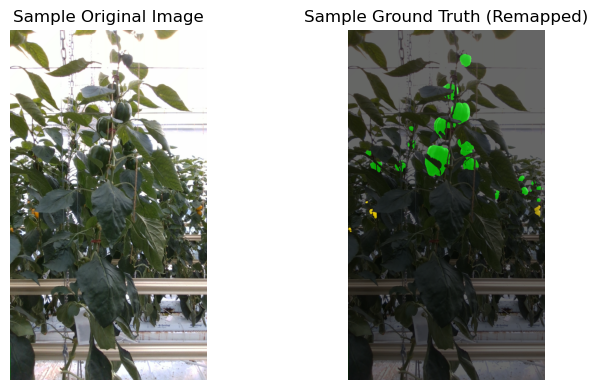

Sample GT shape: torch.Size([1280, 720])
Unique GT labels: [0 3 4 7]


In [48]:
print('🔍 Testing single batch...')
sample_batch = next(iter(test_dataloader))
print(f'Batch shapes:')
print(f'  - pixel_values: {sample_batch["pixel_values"].shape}')
print(f'  - original_images: {len(sample_batch["original_images"])}')
print(f'  - original_segmentation_maps: {len(sample_batch["original_segmentation_maps"])}')
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
orig_img = np.array(sample_batch['original_images'][0])
axes[0].imshow(orig_img)
axes[0].set_title('Sample Original Image')
axes[0].axis('off')
gt_mask = np.array(sample_batch['original_segmentation_maps'][0])
# Remap mask for correct color mapping
remapped_mask = remap_labels(gt_mask, label2id)
custom_cmap = mcolors.ListedColormap(np.array(palette) / 255.0)
axes[1].imshow(orig_img)
axes[1].imshow(remapped_mask, cmap=custom_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
axes[1].set_title('Sample Ground Truth (Remapped)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Sample GT shape: {remapped_mask.shape}')
print(f'Unique GT labels: {np.unique(remapped_mask)}')

## 4. Sequential Ensemble Inference

This section runs inference for each model sequentially to minimize GPU memory usage.

In [49]:
def run_single_model_inference(checkpoint_file, model_dir, dataloader, device, num_classes):
    """Run inference for a single model."""
    print(f"Loading model: {checkpoint_file}")
    
    # Load model
    model = get_mask2former_model(num_labels=num_classes, device=device)
    checkpoint_path = os.path.join(model_dir, checkpoint_file)
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint.get('model_state_dict', checkpoint))
    model.to(device).eval()
    
    # Run inference
    model_predictions = []
    start_time = time.time()
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc=f"Inference")):
            inputs = batch["pixel_values"].to(device)
            outputs = model(inputs)
            
            # Mask2Former output processing
            class_probs = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]  # [B, Q, C]
            masks_probs = outputs.masks_queries_logits.sigmoid()  # [B, Q, H, W]
            
            # Validate shapes
            assert class_probs.shape[1] == masks_probs.shape[1], "Query dimension mismatch"
            
            # Per-pixel class probabilities
            segmentation = torch.einsum("bqc,bqhw->bchw", class_probs, masks_probs)  # [B, C, H, W]
            
            # Resize to input dimensions
            segmentation_resized = F.interpolate(
                segmentation.float(),
                size=(inputs.shape[2], inputs.shape[3]),
                mode="bilinear",
                align_corners=False
            )
            
            # Normalize probabilities
            segmentation_resized = segmentation_resized / (
                segmentation_resized.sum(dim=1, keepdim=True) + 1e-8
            )
            
            model_predictions.append(segmentation_resized.cpu())
            
            # Clear GPU cache periodically
            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()
    
    print(f"Inference time: {time.time() - start_time:.2f}s")
    
    # Concatenate and free GPU memory
    predictions_tensor = torch.cat(model_predictions, dim=0)
    del model
    torch.cuda.empty_cache()
    
    return predictions_tensor

In [50]:
# Run sequential ensemble inference
print("🚀 Starting Sequential Ensemble Inference")
print(f"Processing {len(CONFIG['checkpoint_files'])} models...")

all_model_predictions = []
gt_maps = []
original_images_subset = []

total_start_time = time.time()

for model_idx, checkpoint_file in enumerate(CONFIG['checkpoint_files']):
    print(f"\n🤖 Model {model_idx + 1}/{len(CONFIG['checkpoint_files'])}: {checkpoint_file}")
    
    # Check if checkpoint exists
    checkpoint_path = os.path.join(CONFIG['ensemble_models_dir'], checkpoint_file)
    if not os.path.exists(checkpoint_path):
        print(f"❌ Checkpoint not found: {checkpoint_path}")
        print("Please check the path and filename in CONFIG['checkpoint_files'] and CONFIG['ensemble_models_dir'].")
        break  # Stop execution if checkpoint is missing

    # Run inference for this model
    model_preds = run_single_model_inference(
        checkpoint_file, CONFIG['ensemble_models_dir'], 
        test_dataloader, device, num_classes
    )
    all_model_predictions.append(model_preds)
    
    # Collect ground truth and original images only for first model
    if model_idx == 0:
        print("Collecting ground truth and original images...")
        
        for batch_idx, batch in enumerate(test_dataloader):
            # Ground truth
            gt_raw = batch["original_segmentation_maps"]
            gt_batch = torch.stack([torch.from_numpy(np.array(gt)) for gt in gt_raw])
            
            # Resize GT to match prediction spatial dimensions
            if gt_batch.shape[-2:] != model_preds.shape[-2:]:
                gt_batch = F.interpolate(
                    gt_batch.unsqueeze(1).float(),
                    size=model_preds.shape[-2:],
                    mode='nearest'
                ).squeeze(1).long()
            
            gt_maps.append(gt_batch)
            
            # Collect sample images for visualization
            if batch_idx < 5:
                original_images_subset.extend(batch.get("original_images", []))
    
    print(f"✅ Model {model_idx + 1} completed. GPU memory cleared.")

print(f"\n⏱️  Total inference time: {time.time() - total_start_time:.2f}s")

🚀 Starting Sequential Ensemble Inference
Processing 4 models...

🤖 Model 1/4: best_model_551ouxf3.pt
Loading model: best_model_551ouxf3.pt


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Inference: 100%|██████████| 5/5 [00:26<00:00,  5.24s/it]


Inference time: 26.22s
✅ Model 1 completed. GPU memory cleared.

🤖 Model 2/4: model_epoch60_551ouxf3.pt
Loading model: model_epoch60_551ouxf3.pt


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Inference: 100%|██████████| 5/5 [00:26<00:00,  5.26s/it]


Inference time: 26.32s
✅ Model 2 completed. GPU memory cleared.

🤖 Model 3/4: model_epoch80_551ouxf3.pt
Loading model: model_epoch80_551ouxf3.pt


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Inference: 100%|██████████| 5/5 [00:26<00:00,  5.31s/it]


Inference time: 26.57s
✅ Model 3 completed. GPU memory cleared.

🤖 Model 4/4: model_epoch100_551ouxf3.pt
Loading model: model_epoch100_551ouxf3.pt


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Inference: 100%|██████████| 5/5 [00:26<00:00,  5.31s/it]


Inference time: 26.57s
✅ Model 4 completed. GPU memory cleared.

⏱️  Total inference time: 116.28s


In [51]:
# Stack ensemble predictions and ground truth
print("📊 Stacking ensemble predictions...")

preds_stack = torch.stack(all_model_predictions, dim=0)  # [M, N, C, H, W]
gt_stack = torch.cat(gt_maps, dim=0)                    # [N, H, W]

# Remap the ground truth labels to match the 0-7 format ---
print(f"Remapping ground truth labels to match model output (0-7)...")
print(f"  Labels before remapping: {torch.unique(gt_stack).tolist()}")
gt_stack = remap_labels(gt_stack, label2id) # This overwrites gt_stack with the corrected labels

print(f"  Labels after remapping:  {torch.unique(gt_stack).tolist()}")
print(f"Final shapes:")
print(f"  - Ensemble predictions: {preds_stack.shape} (Models, Samples, Classes, Height, Width)")
print(f"  - Ground truth: {gt_stack.shape} (Samples, Height, Width)")
print(f"  - Original images collected: {len(original_images_subset)}")

# Memory usage
pred_size_gb = preds_stack.numel() * 4 / (1024**3)  # float32 = 4 bytes
gt_size_gb = gt_stack.numel() * 8 / (1024**3)       # int64 = 8 bytes  
print(f"Memory usage: {pred_size_gb:.2f}GB (predictions) + {gt_size_gb:.2f}GB (GT)")

📊 Stacking ensemble predictions...
Remapping ground truth labels to match model output (0-7)...
  Labels before remapping: [0, 12, 13, 14, 17, 18]
  Labels after remapping:  [0, 2, 3, 4, 6, 7]
Final shapes:
  - Ensemble predictions: torch.Size([4, 93, 8, 640, 360]) (Models, Samples, Classes, Height, Width)
  - Ground truth: torch.Size([93, 640, 360]) (Samples, Height, Width)
  - Original images collected: 93
Memory usage: 2.55GB (predictions) + 0.16GB (GT)


In [52]:
# Get the unique labels and their counts from your ground truth test set
unique_labels, counts = torch.unique(gt_stack, return_counts=True)

print("📊 Pixel Counts for Each Class in the Ground Truth Test Set:\n")
for label_id, count in zip(unique_labels.tolist(), counts.tolist()):
    class_name = id2label_remapped.get(label_id, f"Unknown ID: {label_id}")
    print(f"{class_name:<20} | Label ID: {label_id} | Pixel Count: {count}")

📊 Pixel Counts for Each Class in the Ground Truth Test Set:

bg                   | Label ID: 0 | Pixel Count: 20504155
pepper_red           | Label ID: 2 | Pixel Count: 44226
pepper_yellow        | Label ID: 3 | Pixel Count: 54044
pepper_green         | Label ID: 4 | Pixel Count: 649295
pepper_mixed_red     | Label ID: 6 | Pixel Count: 70438
pepper_mixed_yellow  | Label ID: 7 | Pixel Count: 105042


## 5. Uncertainty Computation with TorchUncertainty

Compute ensemble uncertainties using TorchUncertainty's validated metrics.

In [53]:
# def compute_ensemble_uncertainties(preds_stack):
#     """
#     Compute uncertainty decomposition using TorchUncertainty metrics.
    
#     Args:
#         preds_stack: [M, N, C, H, W] ensemble predictions
        
#     Returns:
#         dict with ensemble_mean, total_uncertainty, epistemic_uncertainty, aleatoric_uncertainty
#     """
#     print("📊 Computing ensemble uncertainties using TorchUncertainty...")
#     start_time = time.time()
    
#     # Ensemble mean prediction
#     ensemble_mean = preds_stack.mean(dim=0)  # [N, C, H, W]
    
#     # Initialize TorchUncertainty metrics (base-2 entropy for consistency)
#     entropy_metric = Entropy(normalize=False, log_base=2.0)
#     mi_metric = MutualInformation(normalize=False, log_base=2.0)
    
#     # Total uncertainty: H[mean]
#     total_uncertainty = entropy_metric(ensemble_mean)  # [N, H, W]
    
#     # Epistemic uncertainty: Mutual Information = H[mean] - E[H]
#     epistemic_uncertainty = mi_metric(preds_stack)  # [N, H, W]
    
#     # Aleatoric uncertainty: Total - Epistemic
#     aleatoric_uncertainty = total_uncertainty - epistemic_uncertainty  # [N, H, W]
    
#     print(f"⏱️  Uncertainty computation time: {time.time() - start_time:.2f}s")
    
#     return {
#         'ensemble_mean': ensemble_mean,
#         'total_uncertainty': total_uncertainty,
#         'epistemic_uncertainty': epistemic_uncertainty,
#         'aleatoric_uncertainty': aleatoric_uncertainty
#     }

# # Compute uncertainties
# uncertainty_results = compute_ensemble_uncertainties(preds_stack)

# # Print shapes
# print("\n📏 Uncertainty tensor shapes:")
# for key, tensor in uncertainty_results.items():
#     print(f"  - {key}: {tensor.shape}")

In [54]:
# CORRECTED SECTION 5: Manual Uncertainty Computation

def compute_ensemble_uncertainties_manual(preds_stack):
    """
    Compute uncertainty decomposition using the manual Shannon decomposition.
    This logic is adapted from your ensemble_uncertainty_visualization.py script
    and correctly calculates per-pixel uncertainty for segmentation.
    
    Args:
        preds_stack: [M, N, C, H, W] ensemble predictions (Models, Samples, Classes, Height, Width)
        
    Returns:
        dict with ensemble_mean, total_uncertainty, epistemic_uncertainty, aleatoric_uncertainty
    """
    print("📊 Computing ensemble uncertainties manually (Shannon Decomposition)...")
    start_time = time.time()
    
    # Use a small epsilon for numerical stability in log
    epsilon = 1e-12 
    
    num_models, num_samples, num_classes, height, width = preds_stack.shape

    # 1. Calculate Aleatoric Uncertainty: E[H(y)] (Average entropy of predictions)
    print("   Calculating Aleatoric Uncertainty...")
    log_probs = torch.log2(preds_stack + epsilon)
    entropy_per_model = -torch.sum(preds_stack * log_probs, dim=2)  # Sum over classes (C) -> Shape: [M, N, H, W]
    aleatoric_uncertainty = entropy_per_model.mean(dim=0)            # Average over models (M) -> Shape: [N, H, W]

    # 2. Calculate Total Uncertainty: H[E[y]] (Entropy of the average prediction)
    print("   Calculating Total Uncertainty...")
    ensemble_mean = preds_stack.mean(dim=0)  # Average over models (M) -> Shape: [N, C, H, W]
    
    log_mean_probs = torch.log2(ensemble_mean + epsilon)
    total_uncertainty = -torch.sum(ensemble_mean * log_mean_probs, dim=1) # Sum over classes (C) -> Shape: [N, H, W]

    # 3. Calculate Epistemic Uncertainty: Total - Aleatoric
    print("   Calculating Epistemic Uncertainty...")
    epistemic_uncertainty = total_uncertainty - aleatoric_uncertainty # Shape: [N, H, W]

    print(f"⏱️  Uncertainty computation time: {time.time() - start_time:.2f}s")
    
    return {
        'ensemble_mean': ensemble_mean,
        'total_uncertainty': total_uncertainty,
        'epistemic_uncertainty': epistemic_uncertainty,
        'aleatoric_uncertainty': aleatoric_uncertainty
    }

# Compute uncertainties using the CORRECT manual method
uncertainty_results = compute_ensemble_uncertainties_manual(preds_stack)

# Print shapes (this should now run successfully)
print("\n📏 Uncertainty tensor shapes:")
for key, tensor in uncertainty_results.items():
    print(f"  - {key}: {tensor.shape}")

📊 Computing ensemble uncertainties manually (Shannon Decomposition)...
   Calculating Aleatoric Uncertainty...
   Calculating Total Uncertainty...
   Calculating Epistemic Uncertainty...
⏱️  Uncertainty computation time: 2.19s

📏 Uncertainty tensor shapes:
  - ensemble_mean: torch.Size([93, 8, 640, 360])
  - total_uncertainty: torch.Size([93, 640, 360])
  - epistemic_uncertainty: torch.Size([93, 640, 360])
  - aleatoric_uncertainty: torch.Size([93, 640, 360])


In [55]:
# Quick uncertainty statistics
print("📈 Quick Uncertainty Statistics:")

for unc_type in ['aleatoric_uncertainty', 'epistemic_uncertainty', 'total_uncertainty']:
    unc_tensor = uncertainty_results[unc_type]
    mean_val = unc_tensor.mean().item()
    std_val = unc_tensor.std().item()
    max_val = unc_tensor.max().item()
    min_val = unc_tensor.min().item()
    
    print(f"\n{unc_type.replace('_', ' ').title()}:")
    print(f"  Mean: {mean_val:.4f}, Std: {std_val:.4f}")
    print(f"  Min: {min_val:.4f}, Max: {max_val:.4f}")

📈 Quick Uncertainty Statistics:

Aleatoric Uncertainty:
  Mean: 0.4952, Std: 0.3177
  Min: 0.2630, Max: 2.7195

Epistemic Uncertainty:
  Mean: 0.0085, Std: 0.0100
  Min: 0.0004, Max: 0.6519

Total Uncertainty:
  Mean: 0.5037, Std: 0.3232
  Min: 0.2667, Max: 2.7354


## 6. Metrics Evaluation

Compute segmentation performance and calibration metrics.

In [56]:
def compute_segmentation_metrics(ensemble_mean, gt_labels, num_classes):
    """
    Compute segmentation and calibration metrics using TorchUncertainty.
    
    Returns:
        dict with IoU metrics, calibration errors, and per-class statistics
    """
    print("📏 Computing segmentation and calibration metrics...")
    start_time = time.time()
    
    # Predictions for IoU calculation
    predictions = ensemble_mean.argmax(dim=1)  # Shape: [N, H, W]
    
    # --- MANUAL IoU CALCULATION ---
    # FIX: Bypassing the buggy torchmetrics.MeanIoU by calculating IoU manually.
    
    per_class_iou_list = []
    # Loop over each class to calculate its individual IoU
    for k in range(num_classes):
        # Create binary masks for the current class
        preds_k = (predictions == k)
        target_k = (gt_labels == k)
        
        # Calculate intersection and union
        intersection = (preds_k & target_k).sum()
        union = (preds_k | target_k).sum()
        
        # Calculate IoU, avoiding division by zero
        if union == 0:
            # If there are no ground truth or predictions for this class, IoU is 1.0 (or NaN, your choice)
            # If there are predictions but no GT (or vice versa), union > 0 and IoU will be 0.
            iou_k = torch.tensor(1.0, device=predictions.device) 
        else:
            iou_k = intersection.float() / union.float()
            
        per_class_iou_list.append(iou_k)

    # Convert the list of IoU scores to a tensor
    per_class_iou = torch.stack(per_class_iou_list)
    
    # Calculate the macro-average Mean IoU
    mean_iou = per_class_iou.mean()
    # --- MANUAL IoU CALCULATION ---
    
    # Pixel-wise calibration error
    N, C, H, W = ensemble_mean.shape
    preds_flat = ensemble_mean.reshape(N, C, H * W)  # [N, C, HW]
    target_flat = gt_labels.reshape(N, H * W)        # [N, HW]
    
    # Overall ECE
    cal_metric = CalibrationError(task='multiclass', num_bins=10, norm='l1', num_classes=num_classes)
    overall_ece = cal_metric(preds_flat, target_flat)
    
    # Per-class ECE (binary calibration for each class)
    per_class_ece = []
    for k in range(num_classes):
        class_confidences = preds_flat[:, k, :]  # [N, HW]
        class_targets = (target_flat == k).long()  # [N, HW]
        
        binary_cal = CalibrationError(task='binary', num_bins=10, norm='l1')
        class_ece = binary_cal(class_confidences, class_targets)
        per_class_ece.append(class_ece)
    
    per_class_ece = torch.stack(per_class_ece)
    
    print(f"⏱️  Metrics computation time: {time.time() - start_time:.2f}s")
    
    return {
        'mean_iou': mean_iou,
        'per_class_iou': per_class_iou,
        'overall_ece': overall_ece,
        'per_class_ece': per_class_ece
    }

# Compute metrics
seg_metrics = compute_segmentation_metrics(
    uncertainty_results['ensemble_mean'], gt_stack, num_classes
)

print("\n🎯 Initial Metrics Summary:")
print(f"  Mean IoU: {seg_metrics['mean_iou']:.4f}")
print(f"  Overall ECE: {seg_metrics['overall_ece']:.4f}")

📏 Computing segmentation and calibration metrics...
⏱️  Metrics computation time: 9.31s

🎯 Initial Metrics Summary:
  Mean IoU: 0.6401
  Overall ECE: 0.0196


### 6. a) Plotting caliberation

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.gridspec as gridspec

def plot_calibration_diagrams(ensemble_mean, gt_labels, num_classes, 
                            per_class_ece, overall_ece, num_bins=10, 
                            class_names=None, figsize=(24, 16), save_path=None):
    """
    Plot calibration diagrams for semantic segmentation model with fixed layout.
    
    Args:
        ensemble_mean: Model predictions [N, C, H, W]
        gt_labels: Ground truth labels [N, H, W]  
        num_classes: Number of segmentation classes
        per_class_ece: Per-class ECE values tensor
        overall_ece: Overall ECE value tensor
        num_bins: Number of bins for calibration plots
        class_names: List of class names for labeling
        figsize: Figure size tuple
        save_path: Optional path to save the figure
    """
    
    # Default class names if not provided
    if class_names is None:
        class_names = [f'Class {i}' for i in range(num_classes)]
    
    # Reshape data for calibration computation
    N, C, H, W = ensemble_mean.shape
    preds_flat = ensemble_mean.reshape(N, C, H * W)  # [N, C, HW]
    target_flat = gt_labels.reshape(N, H * W)        # [N, HW]
    
    # Create figure with proper grid layout
    fig = plt.figure(figsize=figsize)
    
    # Create a 4x4 grid to accommodate all plots
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)
    
    # Overall calibration plot (spans 2x2 in top-left)
    ax_main = fig.add_subplot(gs[0:2, 0:2])
    plot_single_calibration(preds_flat, target_flat, num_bins, overall_ece, 
                           ax_main, title='Overall Calibration', task='multiclass')
    
    # Define positions for per-class plots (fill remaining grid positions)
    positions = [
        (0, 2), (0, 3),    # Top right: 2 plots
        (1, 2), (1, 3),    # Second row right: 2 plots  
        (2, 0), (2, 1), (2, 2), (2, 3),  # Third row: 4 plots
        # We can add more positions in row 3 if needed
        (3, 0), (3, 1), (3, 2), (3, 3)   # Fourth row: 4 plots
    ]
    
    # Per-class calibration plots
    for k in range(min(num_classes, len(positions))):
        row, col = positions[k]
        ax = fig.add_subplot(gs[row, col])
        
        # Binary calibration for class k
        class_confidences = preds_flat[:, k, :]  # [N, HW]
        class_targets = (target_flat == k).long()  # [N, HW]
        
        plot_single_calibration(class_confidences, class_targets, num_bins, 
                              per_class_ece[k], ax, 
                              title=f'{class_names[k]}', task='binary')
    
    # Add overall title
    fig.suptitle('Model Calibration Analysis', fontsize=16, y=0.98)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Calibration plots saved to: {save_path}")
    
    plt.show()
    
    # Print ECE summary
    print("\n📊 Calibration Error Summary:")
    print(f"Overall ECE: {overall_ece:.4f}")
    print("\nPer-class ECE:")
    for k in range(num_classes):
        print(f"  {class_names[k]}: {per_class_ece[k]:.4f}")


def plot_single_calibration(predictions, targets, num_bins, ece_value, ax, 
                          title, task='multiclass'):
    """
    Plot a single calibration diagram (reliability diagram) with improved handling.
    
    Args:
        predictions: Model predictions
        targets: Ground truth targets
        num_bins: Number of calibration bins
        ece_value: ECE value for this calibration
        ax: Matplotlib axis to plot on
        title: Plot title
        task: 'binary' or 'multiclass'
    """
    
    # Flatten predictions and targets
    if task == 'multiclass':
        # For multiclass, get max confidence and corresponding predictions
        confidences = F.softmax(predictions, dim=1).max(dim=1)[0].flatten()
        pred_labels = predictions.argmax(dim=1).flatten()
        target_labels = targets.flatten()
        
        # Filter out background or low confidence predictions if needed
        valid_mask = confidences > 0.1  # Minimum confidence threshold
        confidences = confidences[valid_mask]
        pred_labels = pred_labels[valid_mask]
        target_labels = target_labels[valid_mask]
        
        # Accuracy is whether prediction matches target
        correct = (pred_labels == target_labels).float()
        
    else:  # binary
        # For binary, predictions are already confidences
        confidences = predictions.flatten()
        target_labels = targets.flatten()
        
        # Filter out extreme values
        valid_mask = (confidences >= 0.0) & (confidences <= 1.0)
        confidences = confidences[valid_mask]
        target_labels = target_labels[valid_mask]
        
        # Accuracy is the target value itself (0 or 1)
        correct = target_labels.float()
    
    if len(confidences) == 0:
        ax.text(0.5, 0.5, 'No valid predictions', ha='center', va='center', 
                transform=ax.transAxes, fontsize=10)
        ax.set_title(f'{title}\nECE: N/A', fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        return
    
    # Create bins
    bin_boundaries = torch.linspace(0, 1, num_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    # Initialize arrays for calibration data
    bin_accuracies = []
    bin_confidences = []
    bin_counts = []
    
    # Calculate accuracy and confidence for each bin
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Find predictions in this bin
        if bin_lower == bin_boundaries[-2]:  # Last bin includes upper boundary
            in_bin = (confidences >= bin_lower.item()) & (confidences <= bin_upper.item())
        else:
            in_bin = (confidences >= bin_lower.item()) & (confidences < bin_upper.item())
            
        if in_bin.sum() > 0:
            # Calculate accuracy and confidence for this bin
            accuracy_in_bin = correct[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            
            bin_accuracies.append(accuracy_in_bin.item())
            bin_confidences.append(avg_confidence_in_bin.item())
            bin_counts.append(in_bin.sum().item())
        else:
            bin_accuracies.append(0)
            bin_confidences.append((bin_lower.item() + bin_upper.item()) / 2)
            bin_counts.append(0)
    
    # Convert to numpy arrays
    bin_accuracies = np.array(bin_accuracies)
    bin_confidences = np.array(bin_confidences)
    bin_counts = np.array(bin_counts)
    
    # Create calibration plot
    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.7, linewidth=1, label='Perfect Calibration')
    
    # Reliability bars
    total_samples = max(bin_counts.sum(), 1)  # Avoid division by zero
    for i, (conf, acc, count) in enumerate(zip(bin_confidences, bin_accuracies, bin_counts)):
        if count > 0:
            # Color intensity based on number of samples
            alpha = min(0.4 + 0.6 * (count / total_samples * num_bins), 1.0)
            
            # Draw reliability bar
            bar_bottom = min(conf, acc)
            bar_height = abs(conf - acc)
            
            color = 'red' if conf > acc else 'blue'
            width = 0.8 / num_bins
            
            ax.bar(conf, bar_height, bottom=bar_bottom, width=width,
                  alpha=alpha, color=color, edgecolor='black', linewidth=0.5)
            
            # Mark the accuracy point
            ax.plot(conf, acc, 'ko', markersize=3)
    
    # Add confidence histogram at bottom
    if len(confidences) > 0:
        hist_heights, hist_edges = np.histogram(confidences.cpu().numpy(), bins=num_bins, 
                                               range=(0, 1), density=True)
        # Scale histogram to take up bottom 20% of plot
        hist_heights = hist_heights * 0.15 / hist_heights.max() if hist_heights.max() > 0 else hist_heights
        
        for i in range(len(hist_heights)):
            if hist_heights[i] > 0:
                ax.bar((hist_edges[i] + hist_edges[i+1]) / 2, hist_heights[i], 
                      width=(hist_edges[i+1] - hist_edges[i]) * 0.8,
                      alpha=0.3, color='gray', bottom=0)
    
    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Confidence', fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=9)
    ax.set_title(f'{title}\nECE: {ece_value:.4f}', fontsize=10, pad=5)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=8)
    
    # Add legend only for main plot
    if 'Overall' in title:
        ax.legend(loc='upper left', fontsize=8)


# Alternative simplified version for better layout
def plot_calibration_simple(ensemble_mean, gt_labels, num_classes, 
                          per_class_ece, overall_ece, num_bins=10, 
                          class_names=None, save_path=None):
    """
    Simplified calibration plot with just overall + top 6 classes.
    """
    if class_names is None:
        class_names = [f'Class {i}' for i in range(num_classes)]
    
    # Create 2x4 layout
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Model Calibration Analysis', fontsize=16)
    
    N, C, H, W = ensemble_mean.shape
    preds_flat = ensemble_mean.reshape(N, C, H * W)
    target_flat = gt_labels.reshape(N, H * W)
    
    # Overall plot in first position
    plot_single_calibration(preds_flat, target_flat, num_bins, overall_ece,
                           axes[0, 0], title='Overall', task='multiclass')
    
    # Per-class plots (up to 7 classes)
    class_positions = [(0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]
    
    for k in range(min(num_classes, 7)):
        row, col = class_positions[k]
        class_confidences = preds_flat[:, k, :]
        class_targets = (target_flat == k).long()
        
        plot_single_calibration(class_confidences, class_targets, num_bins,
                               per_class_ece[k], axes[row, col],
                               title=class_names[k], task='binary')
    
    # Hide unused subplots
    for k in range(num_classes, 7):
        if k < len(class_positions):
            row, col = class_positions[k]
            axes[row, col].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Calibration plots saved to: {save_path}")
    
    plt.show()
    
    # Print summary
    print(f"\n📊 Overall ECE: {overall_ece:.4f}")
    for k in range(num_classes):
        print(f"  {class_names[k]}: {per_class_ece[k]:.4f}")


In [58]:
def plot_calibration_diagrams_explained(ensemble_mean, gt_labels, num_classes, 
                                       per_class_ece, overall_ece, num_bins=10, 
                                       class_names=None, figsize=(24, 16), save_path=None):
    """
    Plot user-friendly calibration diagrams with clear explanations and visual guides.
    
    Args:
        ensemble_mean: Model predictions [N, C, H, W]
        gt_labels: Ground truth labels [N, H, W]  
        num_classes: Number of segmentation classes
        per_class_ece: Per-class ECE values tensor
        overall_ece: Overall ECE value tensor
        num_bins: Number of bins for calibration plots
        class_names: List of class names for labeling
        figsize: Figure size tuple
        save_path: Optional path to save the figure
    """
    
    # Default class names if not provided
    if class_names is None:
        class_names = [f'Class {i}' for i in range(num_classes)]
    
    # Reshape data for calibration computation
    N, C, H, W = ensemble_mean.shape
    preds_flat = ensemble_mean.reshape(N, C, H * W)  # [N, C, HW]
    target_flat = gt_labels.reshape(N, H * W)        # [N, HW]
    
    # Create figure with explanation panel
    fig = plt.figure(figsize=figsize)
    
    # Create a grid: explanation panel + plots
    gs = gridspec.GridSpec(5, 5, figure=fig, hspace=0.4, wspace=0.3,
                          height_ratios=[1, 2, 2, 2, 0.3], width_ratios=[1, 1, 1, 1, 1])
    
    # Add main title
    fig.suptitle('🎯 Model Calibration Analysis - How Well Does Your Model Know When It\'s Right?', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    # Explanation panel at the top
    ax_explanation = fig.add_subplot(gs[0, :])
    add_explanation_panel(ax_explanation)
    
    # Overall calibration plot (larger subplot)
    ax_main = fig.add_subplot(gs[1:3, 0:2])
    plot_single_calibration_explained(preds_flat, target_flat, num_bins, overall_ece, 
                                    ax_main, title='📊 Overall Model Performance', 
                                    task='multiclass', is_main=True)
    
    # Define positions for per-class plots
    positions = [
        (1, 2), (1, 3), (1, 4),    # Row 1: 3 plots
        (2, 2), (2, 3), (2, 4),    # Row 2: 3 plots
        (3, 0), (3, 1), (3, 2), (3, 3), (3, 4)  # Row 3: 5 plots (if needed)
    ]
    
    # Per-class calibration plots
    for k in range(min(num_classes, len(positions))):
        row, col = positions[k]
        ax = fig.add_subplot(gs[row, col])
        
        # Binary calibration for class k
        class_confidences = preds_flat[:, k, :]  # [N, HW]
        class_targets = (target_flat == k).long()  # [N, HW]
        
        plot_single_calibration_explained(class_confidences, class_targets, num_bins, 
                                        per_class_ece[k], ax, 
                                        title=f'🏷️ {class_names[k]}', task='binary')
    
    # Add interpretation guide at the bottom
    ax_guide = fig.add_subplot(gs[4, :])
    add_interpretation_guide(ax_guide, overall_ece, per_class_ece)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Calibration plots saved to: {save_path}")
    
    plt.show()
    
    # Print detailed summary
    print_calibration_summary(overall_ece, per_class_ece, class_names)


def add_explanation_panel(ax):
    """Add a clear explanation panel at the top of the plot."""
    ax.text(0.02, 0.8, "📖 How to Read These Plots:", fontsize=14, fontweight='bold', 
            transform=ax.transAxes, va='top')
    
    explanation = (
        "• Black dashed line (━━━): Perfect calibration - where confidence matches accuracy\n"
        "• 🔴 Red bars: Model is OVERCONFIDENT (says 80% sure but only 60% correct)\n" 
        "• 🔵 Blue bars: Model is UNDERCONFIDENT (says 60% sure but 80% correct)\n"
        "• 🎯 Goal: Bars should be small and close to the diagonal line\n"
        "• ECE (Expected Calibration Error): Lower is better (0 = perfect, >0.1 = needs improvement)"
    )
    
    ax.text(0.02, 0.7, explanation, fontsize=11, transform=ax.transAxes, va='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')


def plot_single_calibration_explained(predictions, targets, num_bins, ece_value, ax, 
                                    title, task='multiclass', is_main=False):
    """
    Plot a single calibration diagram with enhanced explanations and visual cues.
    """
    
    # Flatten predictions and targets
    if task == 'multiclass':
        confidences = F.softmax(predictions, dim=1).max(dim=1)[0].flatten()
        pred_labels = predictions.argmax(dim=1).flatten()
        target_labels = targets.flatten()
        
        valid_mask = confidences > 0.1
        confidences = confidences[valid_mask]
        pred_labels = pred_labels[valid_mask]
        target_labels = target_labels[valid_mask]
        
        correct = (pred_labels == target_labels).float()
        
    else:  # binary
        confidences = predictions.flatten()
        target_labels = targets.flatten()
        
        valid_mask = (confidences >= 0.0) & (confidences <= 1.0)
        confidences = confidences[valid_mask]
        target_labels = target_labels[valid_mask]
        
        correct = target_labels.float()
    
    if len(confidences) == 0:
        ax.text(0.5, 0.5, '❌ No valid predictions\nfor this class', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
        ax.set_title(f'{title}\nECE: N/A', fontsize=12, pad=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        return
    
    # Create bins and calculate statistics
    bin_boundaries = torch.linspace(0, 1, num_bins + 1)
    bin_accuracies, bin_confidences, bin_counts = [], [], []
    
    for i in range(num_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        
        if i == num_bins - 1:
            in_bin = (confidences >= bin_lower.item()) & (confidences <= bin_upper.item())
        else:
            in_bin = (confidences >= bin_lower.item()) & (confidences < bin_upper.item())
            
        if in_bin.sum() > 0:
            bin_accuracies.append(correct[in_bin].mean().item())
            bin_confidences.append(confidences[in_bin].mean().item())
            bin_counts.append(in_bin.sum().item())
        else:
            bin_accuracies.append(0)
            bin_confidences.append((bin_lower.item() + bin_upper.item()) / 2)
            bin_counts.append(0)
    
    bin_accuracies = np.array(bin_accuracies)
    bin_confidences = np.array(bin_confidences)
    bin_counts = np.array(bin_counts)
    
    # Plot perfect calibration line with enhanced styling
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.8, linewidth=2, 
           label='🎯 Perfect Calibration', zorder=3)
    
    # Enhanced reliability bars with clear color coding
    total_samples = max(bin_counts.sum(), 1)
    
    for i, (conf, acc, count) in enumerate(zip(bin_confidences, bin_accuracies, bin_counts)):
        if count > 0:
            # Color and transparency based on sample size
            alpha = min(0.5 + 0.5 * (count / total_samples * num_bins), 0.9)
            
            # Determine color and create visual cues
            if abs(conf - acc) < 0.05:  # Well calibrated
                color = 'green'
                label_text = 'Well Calibrated' if i == 0 else ""
            elif conf > acc:  # Overconfident
                color = 'red'
                label_text = '🔴 Overconfident' if i == 0 else ""
            else:  # Underconfident
                color = 'blue' 
                label_text = '🔵 Underconfident' if i == 0 else ""
            
            # Draw calibration bar
            bar_bottom = min(conf, acc)
            bar_height = abs(conf - acc)
            width = 0.8 / num_bins
            
            bar = ax.bar(conf, bar_height, bottom=bar_bottom, width=width,
                        alpha=alpha, color=color, edgecolor='black', linewidth=1,
                        label=label_text if label_text else "")
            
            # Mark accuracy point
            ax.plot(conf, acc, 'ko', markersize=5, markeredgecolor='white', 
                   markeredgewidth=1, zorder=4)
            
            # Add value labels for main plot
            if is_main and count > total_samples * 0.1:  # Only for significant bins
                ax.annotate(f'{acc:.2f}', (conf, acc), xytext=(0, 10), 
                           textcoords='offset points', ha='center', fontsize=8,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    
    # Add confidence distribution histogram
    if len(confidences) > 0:
        hist_heights, hist_edges = np.histogram(confidences.cpu().numpy(), 
                                               bins=num_bins, range=(0, 1), density=True)
        hist_heights = hist_heights * 0.15 / max(hist_heights.max(), 0.001)
        
        for i in range(len(hist_heights)):
            if hist_heights[i] > 0:
                ax.bar((hist_edges[i] + hist_edges[i+1]) / 2, hist_heights[i], 
                      width=(hist_edges[i+1] - hist_edges[i]) * 0.8,
                      alpha=0.3, color='gray', bottom=0, 
                      label='📊 Confidence Distribution' if i == 0 else "")
    
    # Enhanced formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Model Confidence →', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual Accuracy ↑', fontsize=11, fontweight='bold')
    
    # Enhanced title with interpretation
    calibration_quality = get_calibration_quality(ece_value.item())
    title_color = {'Excellent': 'green', 'Good': 'orange', 'Needs Improvement': 'red'}[calibration_quality]
    
    ax.set_title(f'{title}\n{calibration_quality}: ECE = {ece_value:.3f}', 
                fontsize=12, pad=10, color=title_color, fontweight='bold')
    
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=10)
    
    # Add legend for main plot
    if is_main:
        ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    
    # Add calibration zones background
    if is_main:
        # Good calibration zone (close to diagonal)
        ax.fill_between([0, 1], [0, 1], [0.1, 1.1], alpha=0.1, color='green', 
                       label='Good Calibration Zone')
        ax.fill_between([0, 1], [-0.1, 0.9], [0, 1], alpha=0.1, color='green')


def add_interpretation_guide(ax, overall_ece, per_class_ece):
    """Add an interpretation guide at the bottom."""
    ax.text(0.02, 0.8, "📋 Quick Interpretation Guide:", 
           fontsize=14, fontweight='bold', transform=ax.transAxes)
    
    # Overall assessment
    overall_quality = get_calibration_quality(overall_ece.item())
    quality_color = {'Excellent': 'green', 'Good': 'orange', 'Needs Improvement': 'red'}[overall_quality]
    
    assessment = f"🎯 Overall Model: {overall_quality} (ECE: {overall_ece:.3f})\n"
    
    # Count class qualities
    qualities = [get_calibration_quality(ece.item()) for ece in per_class_ece]
    excellent_count = qualities.count('Excellent')
    good_count = qualities.count('Good')
    poor_count = qualities.count('Needs Improvement')
    
    assessment += f"📊 Class Performance: {excellent_count} Excellent, {good_count} Good, {poor_count} Need Improvement"
    
    ax.text(0.02, 0.6, assessment, fontsize=12, transform=ax.transAxes,
           bbox=dict(boxstyle="round,pad=0.5", facecolor=quality_color, alpha=0.3))
    
    # Recommendations
    recommendations = get_recommendations(overall_ece.item(), qualities)
    ax.text(0.55, 0.8, "💡 Recommendations:", fontsize=14, fontweight='bold', 
           transform=ax.transAxes)
    ax.text(0.55, 0.6, recommendations, fontsize=11, transform=ax.transAxes,
           bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')


def get_calibration_quality(ece_value):
    """Determine calibration quality based on ECE value."""
    if ece_value <= 0.05:
        return 'Excellent'
    elif ece_value <= 0.15:
        return 'Good'
    else:
        return 'Needs Improvement'


def get_recommendations(overall_ece, class_qualities):
    """Generate specific recommendations based on calibration results."""
    poor_count = class_qualities.count('Needs Improvement')
    
    if overall_ece <= 0.05:
        return "✅ Great job! Your model is well-calibrated.\n   Consider this model ready for deployment."
    elif overall_ece <= 0.15:
        return f"🔧 Good calibration overall.\n   Focus on improving {poor_count} poorly calibrated classes.\n   Consider temperature scaling or Platt scaling."
    else:
        return f"⚠️ Model needs calibration improvement.\n   Recommended: Apply temperature scaling\n   or collect more diverse training data.\n   Consider ensemble methods."


def print_calibration_summary(overall_ece, per_class_ece, class_names):
    """Print a detailed, user-friendly summary."""
    print("\n" + "="*60)
    print("📊 CALIBRATION ANALYSIS SUMMARY")
    print("="*60)
    
    overall_quality = get_calibration_quality(overall_ece.item())
    print(f"🎯 Overall Performance: {overall_quality}")
    print(f"   Expected Calibration Error (ECE): {overall_ece:.4f}")
    
    if overall_ece <= 0.05:
        print("   ✅ Excellent! Your model knows when it's right.")
    elif overall_ece <= 0.15:
        print("   🟡 Good calibration with room for improvement.")
    else:
        print("   🔴 Poor calibration - model confidence doesn't match accuracy.")
    
    print("\n📋 Per-Class Analysis:")
    print("-" * 40)
    
    for i, (ece, name) in enumerate(zip(per_class_ece, class_names)):
        quality = get_calibration_quality(ece.item())
        emoji = "✅" if quality == "Excellent" else "🟡" if quality == "Good" else "🔴"
        print(f"{emoji} {name:15}: {quality:18} (ECE: {ece:.4f})")
    
    print("\n💡 What this means for your semantic segmentation:")
    if overall_ece <= 0.05:
        print("   • Pixel-level predictions are trustworthy")
        print("   • Confidence scores reliably indicate accuracy") 
        print("   • Model ready for critical applications")
    else:
        print("   • Be cautious with high-confidence predictions")
        print("   • Consider post-processing calibration methods")
        print("   • Uncertainty estimates may be unreliable")
    
    print("="*60)


# Simplified version with clear explanations
def plot_calibration_simple_explained(ensemble_mean, gt_labels, num_classes, 
                                    per_class_ece, overall_ece, num_bins=10, 
                                    class_names=None, save_path=None):
    """
    Simplified version with clear explanations - perfect for beginners.
    """
    if class_names is None:
        class_names = [f'Class {i}' for i in range(num_classes)]
    
    # Create 3x3 layout with explanation
    fig = plt.figure(figsize=(20, 14))
    
    # Add main title with explanation
    fig.suptitle('🎯 Model Calibration: Does Your AI Know When It\'s Right?\n'
                'Red bars = Overconfident 🔴 | Blue bars = Underconfident 🔵 | Goal = Small bars near diagonal ━━━', 
                fontsize=16, fontweight='bold', y=0.95)
    
    N, C, H, W = ensemble_mean.shape
    preds_flat = ensemble_mean.reshape(N, C, H * W)
    target_flat = gt_labels.reshape(N, H * W)
    
    # Create subplots
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # Overall plot (top-left, larger)
    ax_main = fig.add_subplot(gs[0, :2])
    plot_single_calibration_explained(preds_flat, target_flat, num_bins, overall_ece,
                                    ax_main, title='📊 Overall Model Performance', 
                                    task='multiclass', is_main=True)
    
    # Class plots (remaining positions)
    positions = [(0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
    
    for k in range(min(num_classes, len(positions))):
        row, col = positions[k]
        ax = fig.add_subplot(gs[row, col])
        
        class_confidences = preds_flat[:, k, :]
        class_targets = (target_flat == k).long()
        
        plot_single_calibration_explained(class_confidences, class_targets, num_bins,
                                        per_class_ece[k], ax,
                                        title=f'🏷️ {class_names[k]}', task='binary')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Calibration plots saved to: {save_path}")
    
    plt.tight_layout()
    plt.show()
    
    # Print beginner-friendly summary
    print_calibration_summary(overall_ece, per_class_ece, class_names)



📊 Generating calibration plots...
📊 Calibration plots saved to: calibration_plots.png


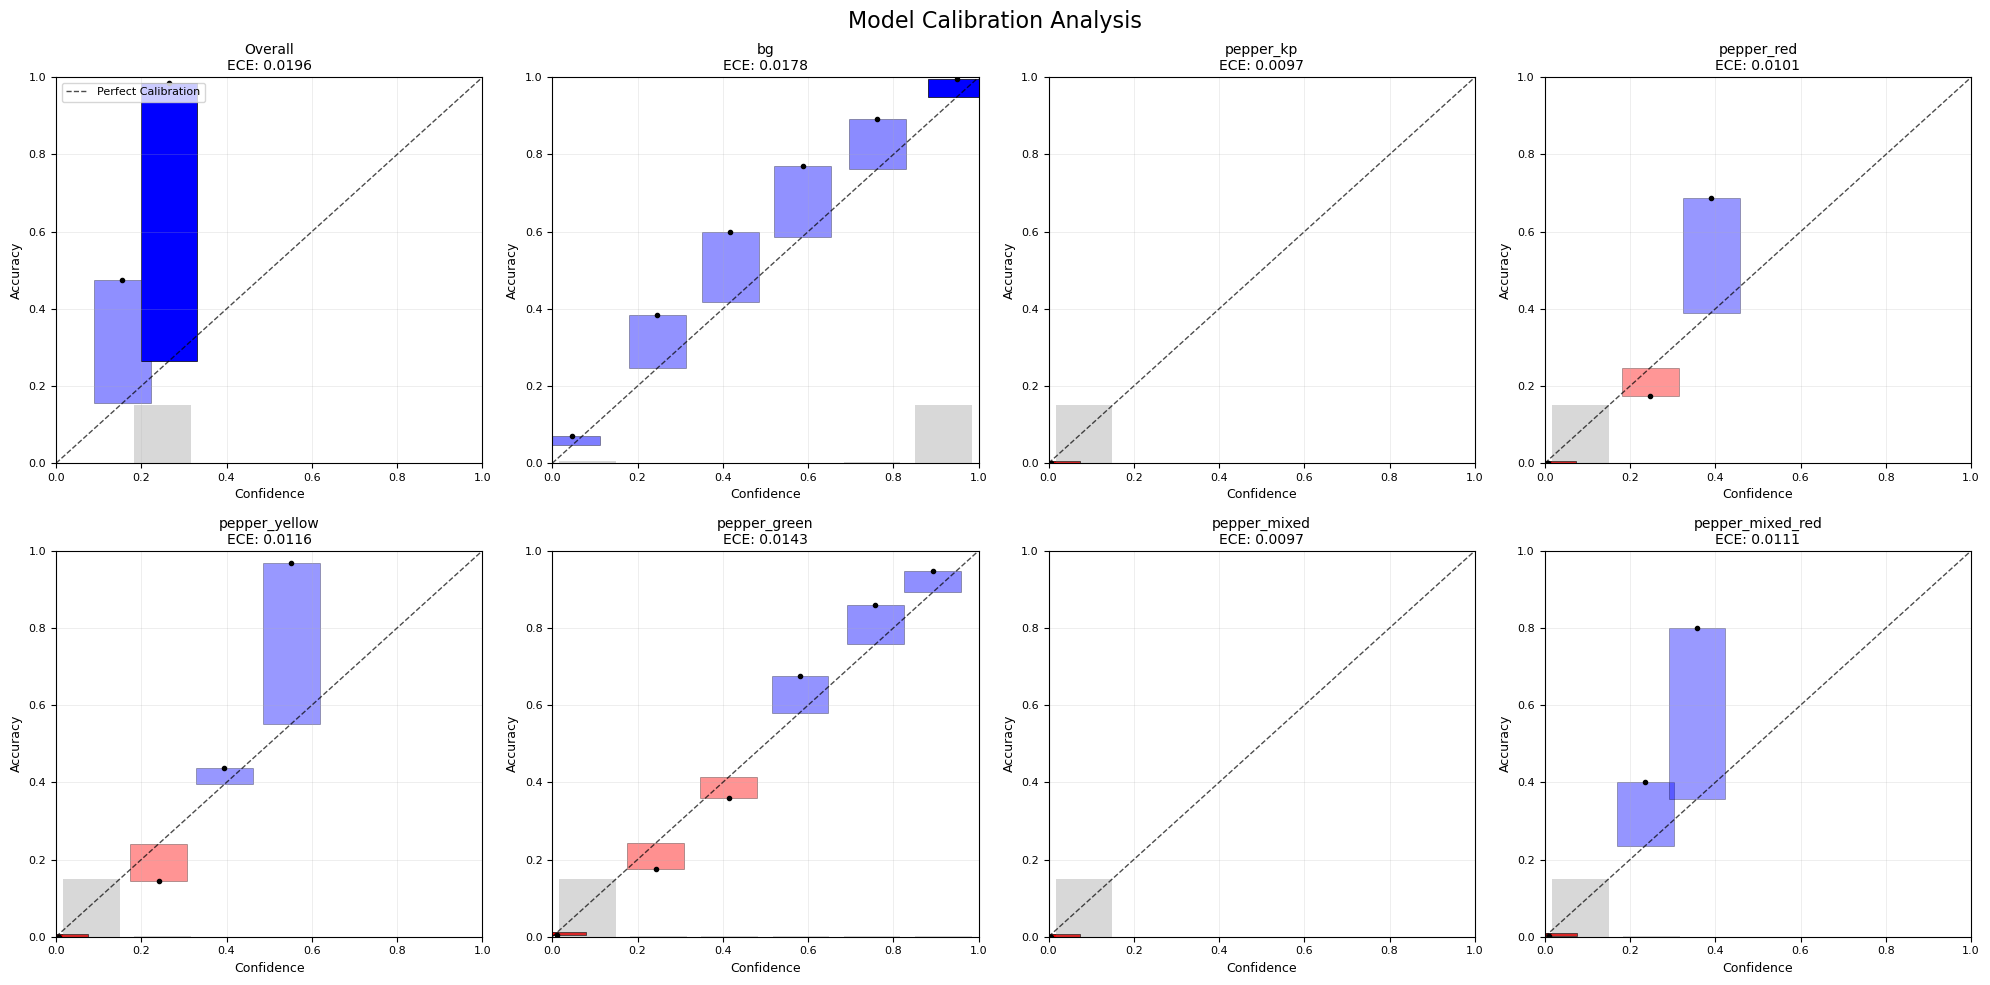


📊 Overall ECE: 0.0196
  bg: 0.0178
  pepper_kp: 0.0097
  pepper_red: 0.0101
  pepper_yellow: 0.0116
  pepper_green: 0.0143
  pepper_mixed: 0.0097
  pepper_mixed_red: 0.0111
  pepper_mixed_yellow: 0.0163


In [59]:
# Define your class names (optional)
class_names = list(id2label_remapped.values())

# Use the simplified version (recommended)
print("\n📊 Generating calibration plots...")
plot_calibration_simple(
    uncertainty_results['ensemble_mean'], 
    gt_stack, 
    num_classes,
    seg_metrics['per_class_ece'],
    seg_metrics['overall_ece'],
    num_bins=6,
    class_names=class_names,
    save_path='calibration_plots.png'
)

# Or use the full version with better grid layout
# plot_calibration_diagrams(
#     uncertainty_results['ensemble_mean'], 
#     gt_stack, 
#     num_classes,
#     seg_metrics['per_class_ece'],
#     seg_metrics['overall_ece'],
#     num_bins=10,
#     class_names=class_names,
#     figsize=(24, 16),
#     save_path='calibration_plots_full.png'
# )

# # Use the explained version (recommended for presentations/reports)
# print("\n📊 Generating user-friendly calibration plots...")
# plot_calibration_diagrams_explained(
#     uncertainty_results['ensemble_mean'], 
#     gt_stack, 
#     num_classes,
#     seg_metrics['per_class_ece'],
#     seg_metrics['overall_ece'],
#     num_bins=10,
#     class_names=class_names,
#     figsize=(24, 16),
#     save_path='calibration_explained.png'
# )

## 7. Per-Class Analysis

In [60]:
def compute_per_class_uncertainty_stats(uncertainty_maps, gt_labels, num_classes):
    """
    Compute per-class uncertainty statistics.
    
    Args:
        uncertainty_maps: dict with uncertainty tensors
        gt_labels: [N, H, W] ground truth labels
        num_classes: int
        
    Returns:
        dict with per-class mean uncertainties
    """
    print("📊 Computing per-class uncertainty statistics...")
    
    stats = {}
    for unc_type, unc_tensor in uncertainty_maps.items():
        if 'uncertainty' in unc_type:
            per_class_means = []
            per_class_stds = []
            per_class_counts = []
            
            for k in range(num_classes):
                class_mask = (gt_labels == k)
                if class_mask.any():
                    class_values = unc_tensor[class_mask]
                    per_class_means.append(class_values.mean().item())
                    per_class_stds.append(class_values.std().item())
                    per_class_counts.append(class_mask.sum().item())
                else:
                    per_class_means.append(0.0)
                    per_class_stds.append(0.0)
                    per_class_counts.append(0)
            
            stats[f'per_class_{unc_type}_mean'] = per_class_means
            stats[f'per_class_{unc_type}_std'] = per_class_stds
            stats[f'per_class_{unc_type}_count'] = per_class_counts
    
    return stats

# Compute per-class statistics
per_class_stats = compute_per_class_uncertainty_stats(
    uncertainty_results, gt_stack, num_classes
)

📊 Computing per-class uncertainty statistics...


In [61]:
# Create comprehensive results table
print("📋 Per-Class Results Table:")
print("=" * 120)
print(f"{'Class':<15} {'IoU':<8} {'ECE':<8} {'Pixels':<10} {'Aleatoric':<12} {'Epistemic':<12} {'Total':<10}")
print("=" * 120)

for k in range(num_classes):
    class_name = id2label_remapped.get(k, f"Class_{k}")
    iou = seg_metrics['per_class_iou'][k].item()
    ece = seg_metrics['per_class_ece'][k].item()
    pixel_count = per_class_stats['per_class_aleatoric_uncertainty_count'][k]
    alea = per_class_stats['per_class_aleatoric_uncertainty_mean'][k]
    epis = per_class_stats['per_class_epistemic_uncertainty_mean'][k]
    total = per_class_stats['per_class_total_uncertainty_mean'][k]
    
    print(f"{class_name:<15} {iou:<8.4f} {ece:<8.4f} {pixel_count:<10} {alea:<12.4f} {epis:<12.4f} {total:<10.4f}")

print("=" * 120)

📋 Per-Class Results Table:
Class           IoU      ECE      Pixels     Aleatoric    Epistemic    Total     
bg              0.9846   0.0178   20504155   0.4557       0.0078       0.4635    
pepper_kp       1.0000   0.0097   0          0.0000       0.0000       0.0000    
pepper_red      0.5166   0.0101   44226      2.2627       0.0360       2.2986    
pepper_yellow   0.4196   0.0116   54044      2.0314       0.0333       2.0647    
pepper_green    0.6442   0.0143   649295     1.0648       0.0191       1.0839    
pepper_mixed    1.0000   0.0097   0          0.0000       0.0000       0.0000    
pepper_mixed_red 0.1181   0.0111   70438      2.1657       0.0333       2.1990    
pepper_mixed_yellow 0.4379   0.0163   105042     2.0284       0.0378       2.0662    


## 8. Visualization

Create uncertainty visualizations for a subset of samples.

In [62]:
def create_uncertainty_visualization(idx, original_img, ensemble_mean, alea, epis, total, gt_mask, palette):
    """
    Create uncertainty visualization for a single sample.
    (This version assumes gt_mask is already remapped).
    """
    # Convert to numpy and get original dimensions
    if isinstance(original_img, Image.Image):
        img_np = np.array(original_img)
    else:
        img_np = original_img
    
    orig_h, orig_w = img_np.shape[:2]
    
    # --- FIX: The gt_mask is now passed pre-remapped, so we just resize it if needed. ---
    gt_mask_remapped = gt_mask.cpu().numpy() if torch.is_tensor(gt_mask) else gt_mask
    if gt_mask_remapped.shape != (orig_h, orig_w):
        gt_tensor = torch.from_numpy(gt_mask_remapped).unsqueeze(0).unsqueeze(0).float()
        gt_mask_remapped = F.interpolate(gt_tensor, size=(orig_h, orig_w), mode='nearest').squeeze().numpy()
    
    # Get prediction mask
    pred_resized = F.interpolate(ensemble_mean.unsqueeze(0), size=(orig_h, orig_w), mode='bilinear', align_corners=False).squeeze(0)
    pred_mask = pred_resized.argmax(dim=0).cpu().numpy()
    
    # Helper to resize uncertainty maps
    def resize_map(tensor_map):
        resized = F.interpolate(
            tensor_map.unsqueeze(0).unsqueeze(0).float(),
            size=(orig_h, orig_w),
            mode='bilinear',
            align_corners=False
        )
        return resized.squeeze().cpu().numpy()

    #------overlay with transparency for better visualization------
    # #Prepare color palette
    # # Convert palette to a NumPy array of floats in the [0, 1] range
    # palette_rgba = np.array(palette, dtype=np.float32) / 255.0

    # # Ensure the palette has 4 channels (RGBA)
    # if palette_rgba.shape[1] == 3:
    #     # If it's only RGB, add an alpha channel of 1.0 (fully opaque)
    #     alpha_channel = np.ones((palette_rgba.shape[0], 1), dtype=np.float32)
    #     palette_rgba = np.hstack((palette_rgba, alpha_channel))
    
    # # Set the alpha of the background color (class 0) to 0.0 (fully transparent)
    # palette_rgba[0, 3] = 0.0
    # seg_cmap = mcolors.ListedColormap(np.array(palette_rgba))
    #-------------------------------------------------------------

    # Create colormaps
    seg_cmap = mcolors.ListedColormap(np.array(palette) / 255.0) # RGB only, no alpha modification
    uncertainty_colors = ['#000033', '#000080', '#0000FF', '#00FFFF', '#FFFF00', '#FF8000', '#FF0000', '#FFFFFF']
    unc_cmap = mcolors.LinearSegmentedColormap.from_list('uncertainty', uncertainty_colors, N=256)
    
    # Create visualization plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Top row: Original, GT, Prediction
    axes[0,0].imshow(img_np)
    axes[0,0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0,0].axis('off')
    
    axes[0,1].imshow(img_np)
    axes[0,1].imshow(gt_mask_remapped, cmap=seg_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
    axes[0,1].set_title('Ground Truth', fontsize=14, fontweight='bold')
    axes[0,1].axis('off')
    
    axes[0,2].imshow(img_np)
    axes[0,2].imshow(pred_mask, cmap=seg_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
    axes[0,2].set_title('Ensemble Prediction', fontsize=14, fontweight='bold')
    axes[0,2].axis('off')
    
    # Bottom row: Uncertainty maps with overlays
    im1 = axes[1,0].imshow(img_np)
    im1 = axes[1,0].imshow(resize_map(alea), cmap=unc_cmap, interpolation='bilinear', vmin=0, alpha=0.6)
    axes[1,0].set_title('Aleatoric Uncertainty\n(Data Noise)', fontsize=14, fontweight='bold')
    axes[1,0].axis('off')
    plt.colorbar(im1, ax=axes[1,0], fraction=0.046, pad=0.04)
    
    im2 = axes[1,1].imshow(img_np)
    im2 = axes[1,1].imshow(resize_map(epis), cmap=unc_cmap, interpolation='bilinear', vmin=0, alpha=0.6)
    axes[1,1].set_title('Epistemic Uncertainty\n(Model Disagreement)', fontsize=14, fontweight='bold')
    axes[1,1].axis('off')
    plt.colorbar(im2, ax=axes[1,1], fraction=0.046, pad=0.04)
    
    im3 = axes[1,2].imshow(img_np)
    im3 = axes[1,2].imshow(resize_map(total), cmap=unc_cmap, interpolation='bilinear', vmin=0, alpha=0.6)
    axes[1,2].set_title('Total Uncertainty', fontsize=14, fontweight='bold')
    axes[1,2].axis('off')
    plt.colorbar(im3, ax=axes[1,2], fraction=0.046, pad=0.04)
    
    plt.suptitle(f'Sample {idx+1}: Uncertainty Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    return fig

🎨 Creating visualizations for 10 samples...


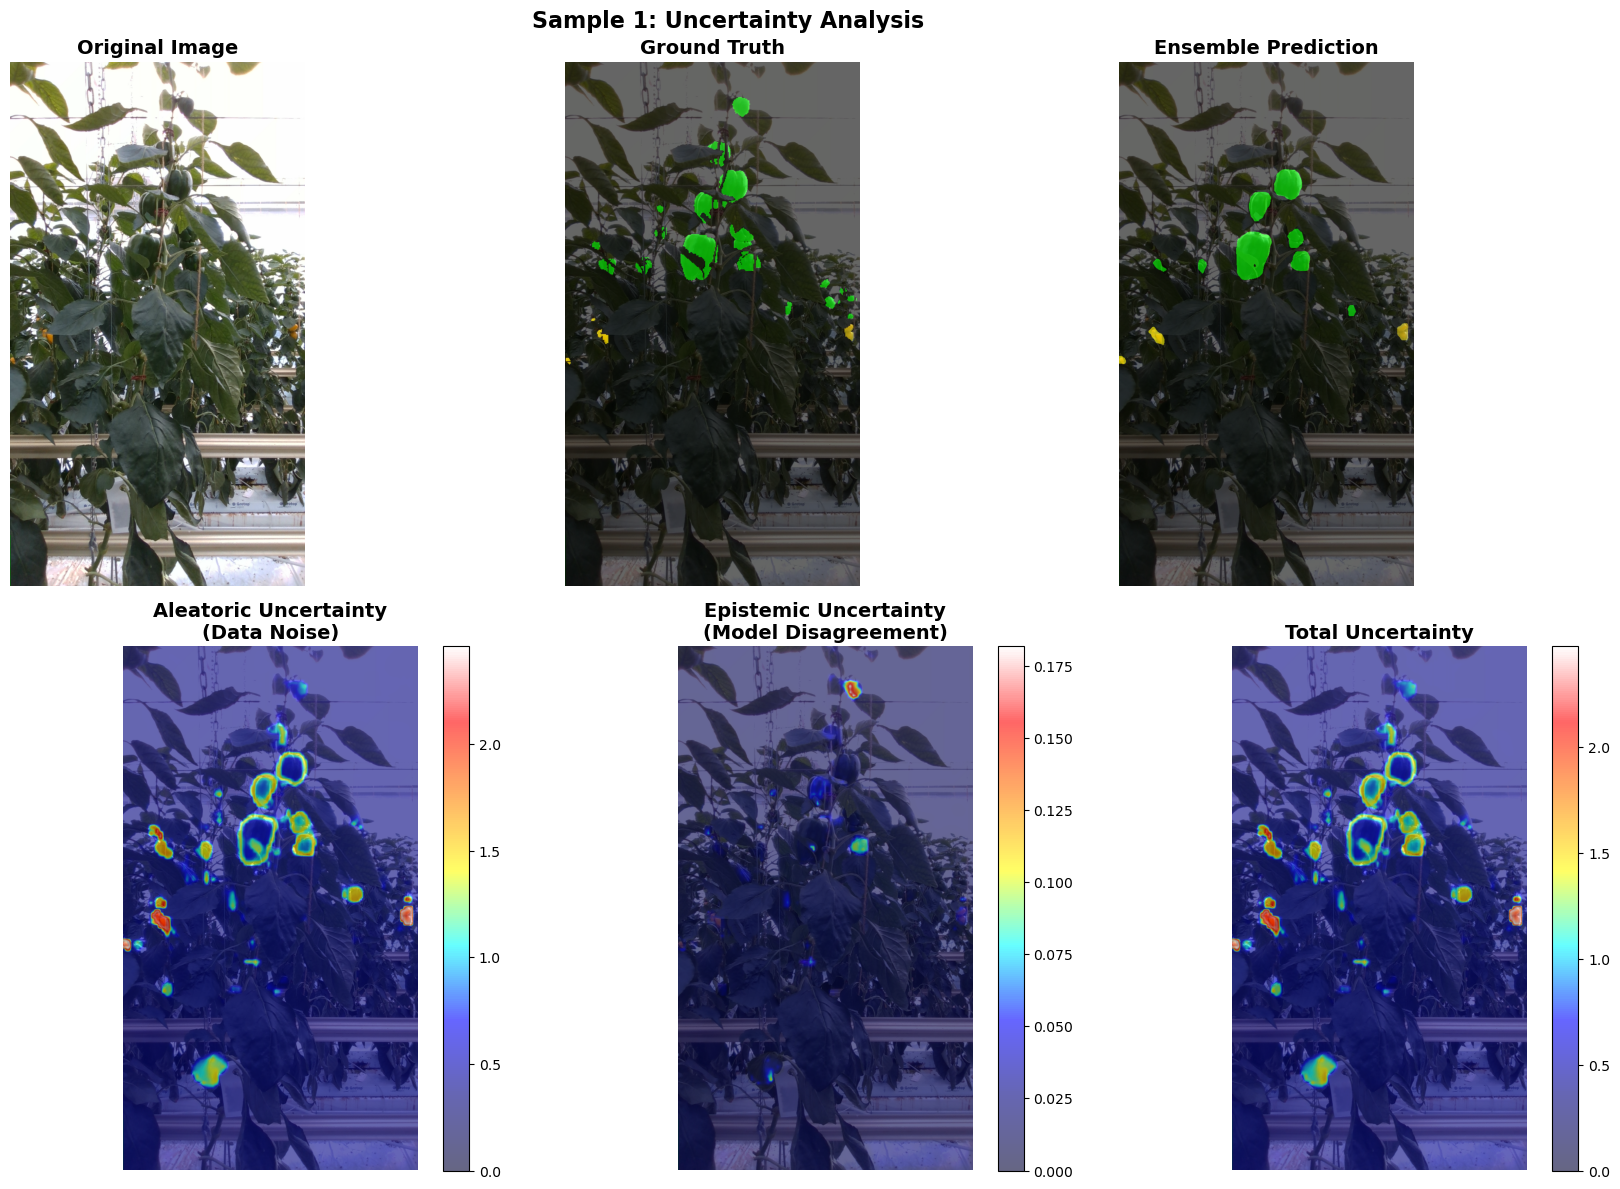

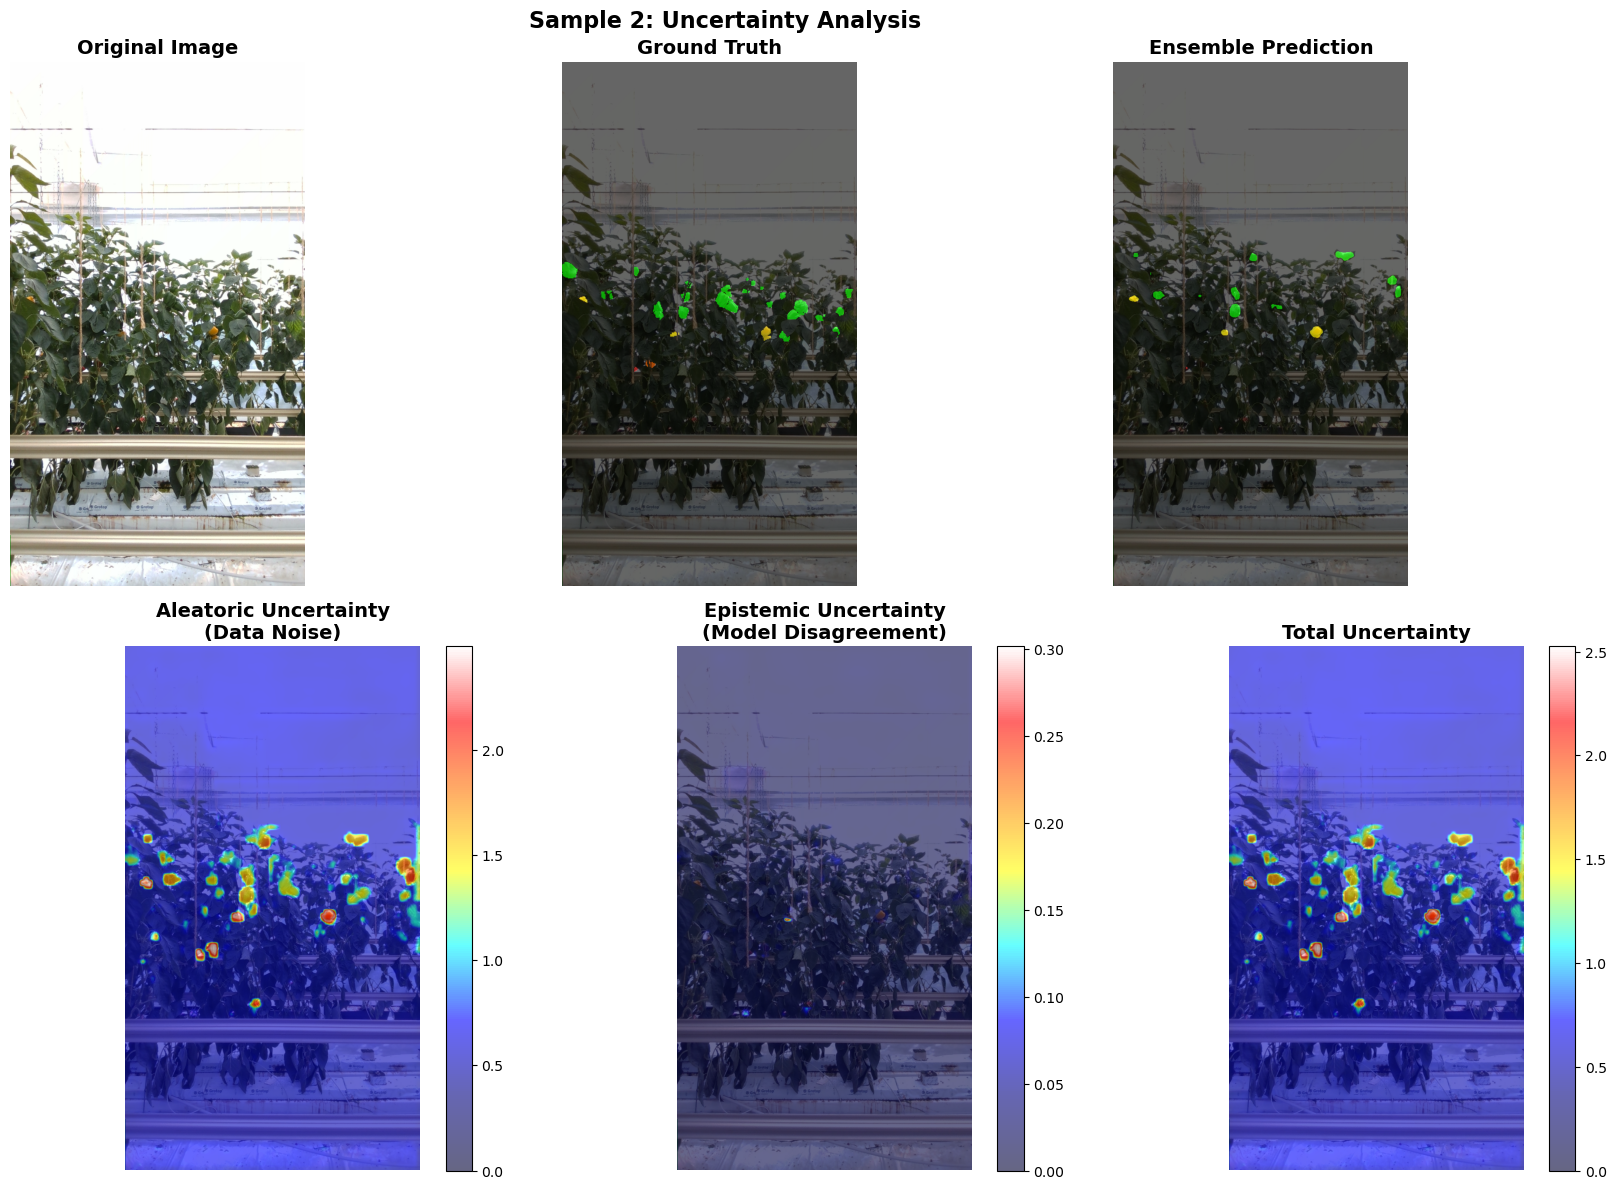

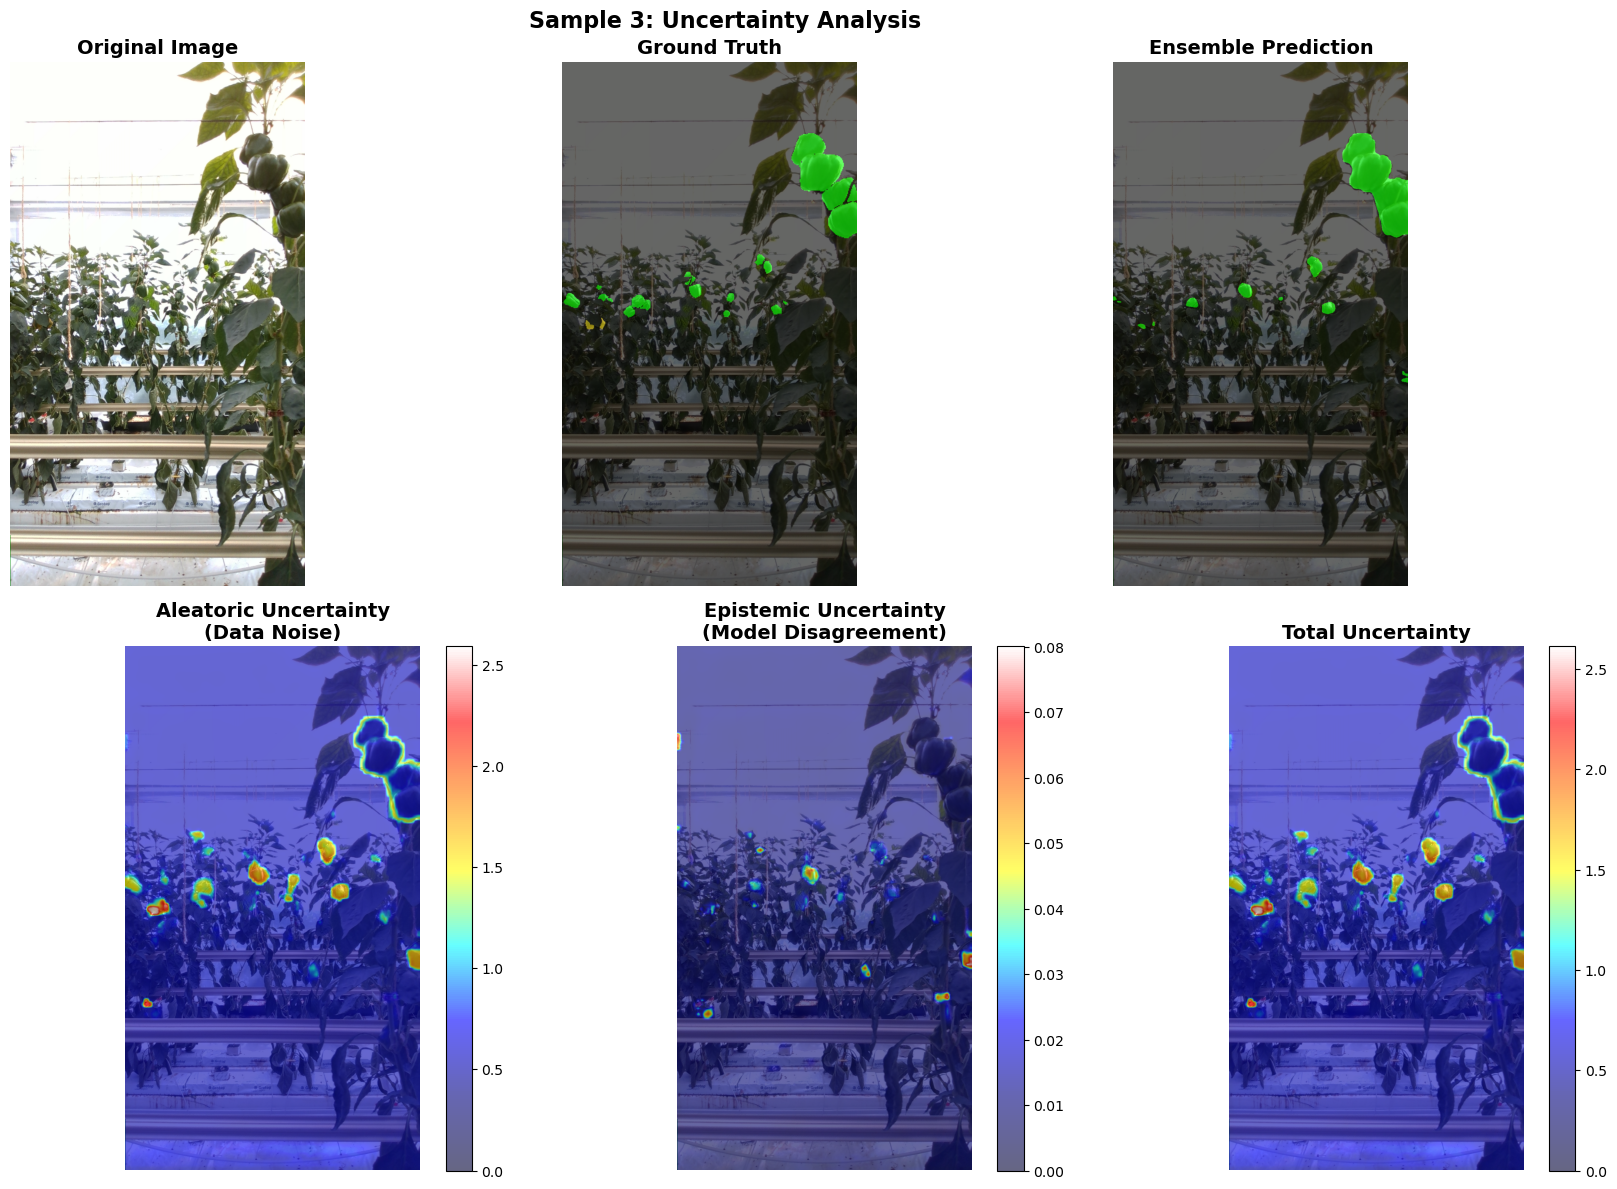

✅ Saved 10 visualizations to Output/uncertainty_visualizations_notebook


In [63]:
# Create visualizations for first few samples
print(f"🎨 Creating visualizations for {min(CONFIG['max_visualize'], len(original_images_subset))} samples...")

max_viz = min(CONFIG['max_visualize'], len(original_images_subset), uncertainty_results['ensemble_mean'].shape[0])

for i in range(max_viz):
    fig = create_uncertainty_visualization(
        i,
        original_images_subset[i],
        uncertainty_results['ensemble_mean'][i],
        uncertainty_results['aleatoric_uncertainty'][i],
        uncertainty_results['epistemic_uncertainty'][i],
        uncertainty_results['total_uncertainty'][i],
        gt_stack[i],
        palette,
    )
    
    # Save visualization
    save_path = os.path.join(CONFIG['output_dir'], f'uncertainty_analysis_{i:03d}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    # Show first few in notebook
    if i < 3:
        plt.show()
    else:
        plt.close(fig)

print(f"✅ Saved {max_viz} visualizations to {CONFIG['output_dir']}")

## 9. Comprehensive Results Summary

In [64]:
# Print comprehensive results
print("\n" + "="*80)
print("🏆 ENSEMBLE UNCERTAINTY ESTIMATION RESULTS")
print("="*80)

print(f"\n📊 Dataset Statistics:")
print(f"  • Total samples: {gt_stack.shape[0]}")
print(f"  • Ensemble models: {len(CONFIG['checkpoint_files'])}")
print(f"  • Number of classes: {num_classes}")
print(f"  • Image dimensions: {preds_stack.shape[-2:]}")

print(f"\n🎯 Segmentation Performance:")
print(f"  • Mean IoU: {seg_metrics['mean_iou']:.4f}")
print(f"  • Overall ECE: {seg_metrics['overall_ece']:.4f}")

print(f"\n🌐 Overall Uncertainty Statistics:")
for unc_type in ['aleatoric_uncertainty', 'epistemic_uncertainty', 'total_uncertainty']:
    unc_tensor = uncertainty_results[unc_type]
    mean_val = unc_tensor.mean().item()
    std_val = unc_tensor.std().item()
    max_val = unc_tensor.max().item()
    display_name = unc_type.replace('_', ' ').title()
    print(f"  • {display_name}: Mean={mean_val:.4f}, Std={std_val:.4f}, Max={max_val:.4f}")

print(f"\n📈 Best Performing Classes (by IoU):")
iou_values = seg_metrics['per_class_iou'].cpu().numpy()
best_classes = np.argsort(iou_values)[::-1][:5]
for rank, k in enumerate(best_classes):
    class_name = id2label_remapped.get(k, f"Class_{k}")
    print(f"  {rank+1}. {class_name}: IoU={iou_values[k]:.4f}")

print(f"\n📉 Classes Needing Improvement (by IoU):")
worst_classes = np.argsort(iou_values)[:5]
for rank, k in enumerate(worst_classes):
    class_name = id2label_remapped.get(k, f"Class_{k}")
    print(f"  {rank+1}. {class_name}: IoU={iou_values[k]:.4f}")

print(f"\n💾 Output Files:")
print(f"  • Visualizations: {CONFIG['output_dir']}")
print(f"  • Number of visualization files: {max_viz}")

print("\n✅ Ensemble uncertainty estimation completed successfully!")
print("="*80)


🏆 ENSEMBLE UNCERTAINTY ESTIMATION RESULTS

📊 Dataset Statistics:
  • Total samples: 93
  • Ensemble models: 4
  • Number of classes: 8
  • Image dimensions: torch.Size([640, 360])

🎯 Segmentation Performance:
  • Mean IoU: 0.6401
  • Overall ECE: 0.0196

🌐 Overall Uncertainty Statistics:
  • Aleatoric Uncertainty: Mean=0.4952, Std=0.3177, Max=2.7195
  • Epistemic Uncertainty: Mean=0.0085, Std=0.0100, Max=0.6519
  • Total Uncertainty: Mean=0.5037, Std=0.3232, Max=2.7354

📈 Best Performing Classes (by IoU):
  1. pepper_mixed: IoU=1.0000
  2. pepper_kp: IoU=1.0000
  3. bg: IoU=0.9846
  4. pepper_green: IoU=0.6442
  5. pepper_red: IoU=0.5166

📉 Classes Needing Improvement (by IoU):
  1. pepper_mixed_red: IoU=0.1181
  2. pepper_yellow: IoU=0.4196
  3. pepper_mixed_yellow: IoU=0.4379
  4. pepper_red: IoU=0.5166
  5. pepper_green: IoU=0.6442

💾 Output Files:
  • Visualizations: Output/uncertainty_visualizations_notebook
  • Number of visualization files: 10

✅ Ensemble uncertainty estimation

In [65]:
# Optional: Save results to file
results_dict = {
    'config': CONFIG,
    'dataset_stats': {
        'num_samples': gt_stack.shape[0],
        'num_models': len(CONFIG['checkpoint_files']),
        'num_classes': num_classes,
        'image_dims': list(preds_stack.shape[-2:])
    },
    'segmentation_metrics': {
        'mean_iou': seg_metrics['mean_iou'].item(),
        'overall_ece': seg_metrics['overall_ece'].item(),
        'per_class_iou': seg_metrics['per_class_iou'].cpu().numpy().tolist(),
        'per_class_ece': seg_metrics['per_class_ece'].cpu().numpy().tolist()
    },
    'uncertainty_stats': {
        'aleatoric': {
            'mean': uncertainty_results['aleatoric_uncertainty'].mean().item(),
            'std': uncertainty_results['aleatoric_uncertainty'].std().item(),
            'max': uncertainty_results['aleatoric_uncertainty'].max().item()
        },
        'epistemic': {
            'mean': uncertainty_results['epistemic_uncertainty'].mean().item(),
            'std': uncertainty_results['epistemic_uncertainty'].std().item(),
            'max': uncertainty_results['epistemic_uncertainty'].max().item()
        },
        'total': {
            'mean': uncertainty_results['total_uncertainty'].mean().item(),
            'std': uncertainty_results['total_uncertainty'].std().item(),
            'max': uncertainty_results['total_uncertainty'].max().item()
        }
    },
    'per_class_stats': per_class_stats
}

# Save to JSON
import json
results_path = os.path.join(CONFIG['output_dir'], 'results_summary.json')
with open(results_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"💾 Results saved to: {results_path}")

💾 Results saved to: Output/uncertainty_visualizations_notebook/results_summary.json


## Summary

This notebook has successfully computed ensemble uncertainty estimation for semantic segmentation using:

1. **Sequential Model Inference** - Memory-efficient processing of 6 ensemble models
2. **TorchUncertainty Metrics** - Validated uncertainty decomposition (aleatoric, epistemic, total)
3. **Comprehensive Evaluation** - IoU, calibration error, AUSE for uncertainty quality
4. **Per-Class Analysis** - Detailed statistics for each semantic class
5. **Visualizations** - Uncertainty maps overlaid on original images

The results provide insights into:
- Model performance across different classes
- Uncertainty patterns in predictions
- Calibration quality for reliable confidence estimates
- Areas where the model is most/least confident

You can now use these insights to improve your models or make better decisions in uncertainty-critical applications.

# Attention visualization of Mask2Former model

In [66]:
# Import necessary libraries
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import warnings
import os
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor

warnings.filterwarnings("ignore")

# ======================= CONFIGURATION =======================
# 1. Your custom model checkpoint path is set.
if os.name == 'darwin':  # macOS
    MODEL_CHECKPOINT_PATH = '/Users/rk/Downloads/Thesis/Output/best_model_551ouxf3.pt'

MODEL_CHECKPOINT_PATH = '/scratch/s7rakuma/MUSH/Output/best_model_551ouxf3.pt'
# 2. SET THE NUMBER OF IMAGES YOU WANT TO VISUALIZE FROM A BATCH
NUM_IMAGES_TO_VISUALIZE = 3

# 3. SET THE NAME OF THE LAYER TO VISUALIZE
TARGET_LAYER_NAME = "model.pixel_level_module.decoder"
# =============================================================

# --- MOCK SETUP (for standalone execution) ---
try:
    batch = next(iter(test_dataloader))
    print("\n✅ Successfully loaded a batch from the test dataloader.")
except NameError:
    print("⚠️ 'test_dataloader' not found. Creating dummy data for demonstration.")
    dummy_image_pil = Image.open("image_1a64cb.jpg").convert("RGB")
    processor = Mask2FormerImageProcessor(size={"height": 512, "width": 512}, do_reduce_labels=False)
    # Create a dummy batch with multiple copies of the same image
    dummy_pixel_values_list = []
    dummy_images_list = []
    for _ in range(NUM_IMAGES_TO_VISUALIZE):
        dummy_pixel_values_list.append(processor.preprocess(dummy_image_pil, return_tensors="pt")['pixel_values'][0])
        dummy_images_list.append(np.array(dummy_image_pil))
    
    batch = {
        'pixel_values': torch.stack(dummy_pixel_values_list),
        'original_images': dummy_images_list
    }
    id2label_remapped = {i: f"class_{i}" for i in range(9)}
    id2label_remapped[0] = "background"


# --- 1. SETUP AND MODEL LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = len(id2label_remapped)

def get_mask2former_model(num_labels, device, checkpoint_path=None):
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        "facebook/mask2former-swin-base-ade-semantic",
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )
    
    if checkpoint_path:
        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(f"Checkpoint file not found at: {checkpoint_path}")
        print(f"\nINFO: Loading trained weights from local checkpoint: {checkpoint_path}")
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
    else:
        print("\nINFO: Loading pretrained weights from Hugging Face hub.")

    model.to(device)
    model.eval()
    return model

try:
    model = get_mask2former_model(num_labels, device, checkpoint_path=MODEL_CHECKPOINT_PATH)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"❌ An error occurred while loading the model: {e}")
    model = None



✅ Successfully loaded a batch from the test dataloader.


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



INFO: Loading trained weights from local checkpoint: /scratch/s7rakuma/MUSH/Output/best_model_551ouxf3.pt
✅ Model loaded successfully.


#### Only pixel decoder feature map

In [80]:

# --- 2. FEATURE MAP VISUALIZER CLASS ---
class FeatureMapVisualizer:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer_name = target_layer_name
        self.feature_maps = None
        self.hook_handle = None
        
        # --- CUSTOM COLORMAP DEFINITION ---
        # Create a matplotlib colormap object from your list of hex colors.
        uncertainty_colors = ['#000033', '#000080', '#0000FF', '#00FFFF', '#FFFF00', '#FF8000', '#FF0000', '#FFFFFF']
        self.custom_cmap = LinearSegmentedColormap.from_list('custom_uncertainty', uncertainty_colors)

    def _hook_fn(self, module, input, output):
        self.feature_maps = output[0][0].detach()

    def _register_hook(self):
        target_layer = dict(self.model.named_modules()).get(self.target_layer_name)
        if target_layer is None:
            raise AttributeError(f"Layer '{self.target_layer_name}' not found in model.")
        self.hook_handle = target_layer.register_forward_hook(self._hook_fn)

    def _remove_hook(self):
        if self.hook_handle:
            self.hook_handle.remove()

    def _create_overlay(self, original_image, feature_map):
        """Upscales, normalizes, and overlays the feature map on the image."""
        upscaled_map = F.interpolate(
            feature_map.unsqueeze(0).unsqueeze(0),
            size=original_image.size[::-1],
            mode='bilinear',
            align_corners=False
        ).squeeze().cpu().numpy()

        norm_map = (upscaled_map - upscaled_map.min()) / (upscaled_map.max() - upscaled_map.min() + 1e-6)
        
        # Apply your custom colormap
        heatmap = (self.custom_cmap(norm_map)[:, :, :3] * 255).astype(np.uint8)
        heatmap_pil = Image.fromarray(heatmap)

        return Image.blend(original_image, heatmap_pil, alpha=0.5)

    def visualize(self, original_image_pil, pixel_values, image_index=0):
        if not self.model: return
        print(f"\n✨ Visualizing feature maps for image {image_index + 1} from layer: '{self.target_layer_name}'")

        self._register_hook()
        with torch.no_grad():
            self.model(pixel_values.to(device))
        self._remove_hook()

        if self.feature_maps is None:
            print("❌ Failed to capture feature maps.")
            return
            
        fm = self.feature_maps[0]

        min_map, mean_map, max_map = torch.min(fm, dim=0)[0], torch.mean(fm, dim=0), torch.max(fm, dim=0)[0]
        
        overlay_min, overlay_mean, overlay_max = (
            self._create_overlay(original_image_pil, min_map),
            self._create_overlay(original_image_pil, mean_map),
            self._create_overlay(original_image_pil, max_map)
        )
        
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f"Model's Spatial Focus (Image {image_index + 1})", fontsize=16)
        
        axes[0].imshow(original_image_pil); axes[0].set_title("Original"); axes[0].axis('off')
        axes[1].imshow(overlay_min); axes[1].set_title("Min"); axes[1].axis('off')
        axes[2].imshow(overlay_mean); axes[2].set_title("Mean"); axes[2].axis('off')
        axes[3].imshow(overlay_max); axes[3].set_title("Max"); axes[3].axis('off')
        
        # Add a color bar using your custom colormap
        norm = plt.Normalize(vmin=0, vmax=1)
        sm = plt.cm.ScalarMappable(cmap=self.custom_cmap, norm=norm)
        sm.set_array([])
        fig.subplots_adjust(right=0.85)
        cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label('Normalized Activation', rotation=270, labelpad=15)

        plt.show()


#### Visualize Pixel decoder + trasformer layer (cross attention)

In [78]:
class FeatureMapVisualizer:
    def __init__(self, model, target_layer_name, palette):
        self.model = model
        self.target_layer_name = target_layer_name
        self.feature_maps = None
        self.hook_handle = None
        
        # --- UPDATED COLORMAPS (matching uncertainty visualization) ---
        # Use the same uncertainty colormap from your uncertainty visualization
        uncertainty_colors = ['#000033', '#000080', '#0000FF', '#00FFFF', '#FFFF00', '#FF8000', '#FF0000', '#FFFFFF']
        self.unc_cmap = mcolors.LinearSegmentedColormap.from_list('uncertainty', uncertainty_colors, N=256)
        
        # Use palette parameter for segmentation colormap (matching your uncertainty visualization)
        self.seg_cmap = mcolors.ListedColormap(np.array(palette) / 255.0)
    
    def _hook_fn(self, module, input, output):
        """ENHANCED hook function to handle both pixel decoder AND cross-attention outputs."""
        try:
            # Check if this is a cross-attention layer
            if 'cross_attn' in self.target_layer_name:
                print(f"   Processing cross-attention output type: {type(output)}")
                
                # Cross-attention can return different formats
                if isinstance(output, tuple) and len(output) > 1:
                    attn_output = output[0]  # The actual output
                    attn_weights = output[1] if len(output) > 1 else None  # Attention weights
                    
                    print(f"   Attention output shape: {attn_output.shape if attn_output is not None else 'None'}")
                    print(f"   Attention weights shape: {attn_weights.shape if attn_weights is not None else 'None'}")
                    
                    # FIXED: Handle 3D attention weights [batch, queries, spatial]
                    if attn_weights is not None:
                        if len(attn_weights.shape) == 3:  # [batch, queries, spatial] - ALREADY AVERAGED!
                            batch_size, num_queries, spatial_dim = attn_weights.shape
                            
                            # Calculate spatial dimensions
                            h = w = int(spatial_dim ** 0.5)
                            
                            if h * w == spatial_dim:  # Perfect square
                                # Reshape to spatial format
                                spatial_attn = attn_weights.view(batch_size, num_queries, h, w)
                                
                                # Store as [queries, h, w] for visualization
                                self.feature_maps = spatial_attn[0].detach()
                                print(f"✅ SUCCESS: Captured cross-attention maps with shape: {self.feature_maps.shape}")
                                print(f"   Spatial dimensions: {h}x{w}")
                            else:
                                print(f"   ❌ Spatial dimension {spatial_dim} is not a perfect square")
                                self.feature_maps = None
                                
                        elif len(attn_weights.shape) == 4:  # [batch, heads, queries, spatial]
                            batch_size, num_heads, num_queries, spatial_dim = attn_weights.shape
                            
                            # Calculate spatial dimensions
                            h = w = int(spatial_dim ** 0.5)
                            
                            if h * w == spatial_dim:  # Perfect square
                                # Average across attention heads
                                spatial_attn = attn_weights.mean(dim=1)  # [batch, queries, spatial]
                                spatial_attn = spatial_attn.view(batch_size, num_queries, h, w)
                                
                                # Store as [queries, h, w] for visualization
                                self.feature_maps = spatial_attn[0].detach()
                                print(f"✅ SUCCESS: Captured cross-attention maps with shape: {self.feature_maps.shape}")
                                print(f"   Spatial dimensions: {h}x{w}")
                            else:
                                print(f"   ❌ Spatial dimension {spatial_dim} is not a perfect square")
                                self.feature_maps = None
                        else:
                            print(f"   ❌ Unexpected attention weights shape: {attn_weights.shape}")
                            self.feature_maps = None
                    else:
                        print("   ❌ No attention weights found in cross-attention output")
                        self.feature_maps = None
                else:
                    print(f"   ❌ Unexpected cross-attention output format: {type(output)}")
                    self.feature_maps = None
            
            # Handle non-cross-attention layers (your original logic)
            else:
                if hasattr(output, 'multi_scale_features'):
                    if output.multi_scale_features:
                        self.feature_maps = output.multi_scale_features[-1].detach()
                    else:
                        self.feature_maps = None
                elif hasattr(output, 'last_hidden_state'):
                    self.feature_maps = output.last_hidden_state.detach()
                elif isinstance(output, (list, tuple)):
                    if len(output) > 0 and hasattr(output[0], 'detach'):
                        if isinstance(output[0], (list, tuple)) and len(output[0]) > 0:
                            self.feature_maps = output[0][0].detach()
                        else:
                            self.feature_maps = output[0].detach()
                    else:
                        self.feature_maps = None
                elif hasattr(output, 'detach'):
                    self.feature_maps = output.detach()
                else:
                    print(f"   Unexpected output type: {type(output)}")
                    self.feature_maps = None
        except Exception as e:
            print(f"   Hook function error: {e}")
            self.feature_maps = None
    
    def _register_hook(self):
        target_layer = dict(self.model.named_modules()).get(self.target_layer_name)
        if target_layer is None:
            raise AttributeError(f"Layer '{self.target_layer_name}' not found in model.")
        self.hook_handle = target_layer.register_forward_hook(self._hook_fn)
    
    def _remove_hook(self):
        if self.hook_handle:
            self.hook_handle.remove()
    
    def _process_segmentation_output(self, outputs, original_size):
        """Process model outputs to get segmentation masks using the same logic as run_single_model_inference."""
        try:
            # Mask2Former output processing (from your inference function)
            class_probs = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]  # [B, Q, C]
            masks_probs = outputs.masks_queries_logits.sigmoid()  # [B, Q, H, W]
            
            # Validate shapes
            assert class_probs.shape[1] == masks_probs.shape[1], "Query dimension mismatch"
            
            # Per-pixel class probabilities
            segmentation = torch.einsum("bqc,bqhw->bchw", class_probs, masks_probs)  # [B, C, H, W]
            
            # Resize to original image size
            segmentation_resized = F.interpolate(
                segmentation.float(),
                size=original_size[::-1],  # PIL size is (W, H), but F.interpolate expects (H, W)
                mode="bilinear",
                align_corners=False
            )
            
            # Normalize probabilities
            segmentation_resized = segmentation_resized / (
                segmentation_resized.sum(dim=1, keepdim=True) + 1e-8
            )
            
            # Get final segmentation mask by taking argmax
            pred_mask = segmentation_resized.argmax(dim=1)[0].cpu().numpy()  # [H, W]
            
            return pred_mask
            
        except Exception as e:
            print(f"   Segmentation processing error: {e}")
            return None
    
    def resize_map(self, tensor_map, target_size):
        """Helper to resize feature/attention maps - matches uncertainty visualization approach."""
        resized = F.interpolate(
            tensor_map.unsqueeze(0).unsqueeze(0).float(),
            size=target_size,
            mode='bilinear',
            align_corners=False
        )
        return resized.squeeze().cpu().numpy()
    
    def visualize(self, original_image_pil, pixel_values, image_index=0):
        if not self.model: 
            return
            
        print(f"\n✨ Visualizing feature maps + segmentation for image {image_index + 1}")
        print(f"   Target layer: '{self.target_layer_name}'")
        
        # Convert PIL to numpy for consistency with uncertainty visualization
        img_np = np.array(original_image_pil)
        orig_h, orig_w = img_np.shape[:2]
        
        # Register hook and run model
        self._register_hook()
        try:
            with torch.no_grad():
                outputs = self.model(pixel_values.to(device))
        finally:
            self._remove_hook()
        
        # Process segmentation
        original_size = original_image_pil.size
        seg_mask = self._process_segmentation_output(outputs, original_size)
        
        # Process feature maps
        if self.feature_maps is not None:
            try:
                fm = self.feature_maps
                if len(fm.shape) == 4:
                    fm = fm[0]  # Remove batch dimension
                
                # ENHANCED: Handle cross-attention maps [queries, H, W]
                if 'cross_attn' in self.target_layer_name and len(fm.shape) == 3:
                    print(f"✅ Captured cross-attention maps with shape: {fm.shape}")
                    print(f"   Value range: [{fm.min():.3f}, {fm.max():.3f}]")
                    
                    # Visualize first 4 most active queries (uncertainty-style layout)
                    query_activations = torch.mean(torch.abs(fm), dim=(1, 2))  # [queries]
                    top_queries = torch.argsort(query_activations, descending=True)[:4]
                    
                    # Create visualization using uncertainty visualization layout (2x3 grid)
                    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
                    
                    # Top row: Original, Segmentation, Top Query
                    axes[0,0].imshow(img_np)
                    axes[0,0].set_title('Original Image', fontsize=14, fontweight='bold')
                    axes[0,0].axis('off')
                    
                    if seg_mask is not None:
                        axes[0,1].imshow(img_np)
                        axes[0,1].imshow(seg_mask, cmap=self.seg_cmap, alpha=0.6, vmin=0, vmax=len(self.seg_cmap.colors)-1)
                        axes[0,1].set_title('Predicted Segmentation', fontsize=14, fontweight='bold')
                    else:
                        axes[0,1].imshow(img_np)
                        axes[0,1].set_title('Segmentation (N/A)', fontsize=14, fontweight='bold')
                    axes[0,1].axis('off')
                    
                    # Top Query attention map
                    if len(top_queries) > 0:
                        top_query_map = self.resize_map(fm[top_queries[0]], (orig_h, orig_w))
                        im1 = axes[0,2].imshow(img_np)
                        im1 = axes[0,2].imshow(top_query_map, cmap=self.unc_cmap, interpolation='bilinear', alpha=0.6)
                        activation_strength = query_activations[top_queries[0]].item()
                        axes[0,2].set_title(f'Top Query {top_queries[0].item()}\n(Activation: {activation_strength:.3f})', fontsize=14, fontweight='bold')
                        axes[0,2].axis('off')
                        plt.colorbar(im1, ax=axes[0,2], fraction=0.046, pad=0.04)
                    
                    # Bottom row: Next 3 most active queries
                    for i in range(3):
                        if i + 1 < len(top_queries):
                            query_idx = top_queries[i + 1]
                            query_map = self.resize_map(fm[query_idx], (orig_h, orig_w))
                            im = axes[1,i].imshow(img_np)
                            im = axes[1,i].imshow(query_map, cmap=self.unc_cmap, interpolation='bilinear', alpha=0.6)
                            activation_strength = query_activations[query_idx].item()
                            axes[1,i].set_title(f'Query {query_idx.item()}\n(Activation: {activation_strength:.3f})', fontsize=14, fontweight='bold')
                            axes[1,i].axis('off')
                            plt.colorbar(im, ax=axes[1,i], fraction=0.046, pad=0.04)
                        else:
                            axes[1,i].axis('off')
                    
                    plt.suptitle(f'Cross-Attention Analysis: {self.target_layer_name.split(".")[-2]} - Sample {image_index+1}', fontsize=16, fontweight='bold')
                    plt.tight_layout()
                    plt.show()
                    
                # Handle pixel decoder maps [C, H, W] using uncertainty-style layout
                elif len(fm.shape) == 3:
                    print(f"✅ Captured feature maps with shape: {fm.shape}")
                    print(f"   Value range: [{fm.min():.3f}, {fm.max():.3f}]")
                    
                    # Compute different feature aggregations
                    min_map = self.resize_map(torch.min(fm, dim=0)[0], (orig_h, orig_w))
                    mean_map = self.resize_map(torch.mean(fm, dim=0), (orig_h, orig_w))
                    max_map = self.resize_map(torch.max(fm, dim=0)[0], (orig_h, orig_w))
                    mean_abs_map = self.resize_map(torch.mean(torch.abs(fm), dim=0), (orig_h, orig_w))
                    
                    # Create visualization using uncertainty visualization layout (2x3 grid)
                    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
                    
                    # Top row: Original, Segmentation, Mean activation
                    axes[0,0].imshow(img_np)
                    axes[0,0].set_title('Original Image', fontsize=14, fontweight='bold')
                    axes[0,0].axis('off')
                    
                    if seg_mask is not None:
                        axes[0,1].imshow(img_np)
                        axes[0,1].imshow(seg_mask, cmap=self.seg_cmap, alpha=0.6, vmin=0, vmax=len(self.seg_cmap.colors)-1)
                        axes[0,1].set_title('Predicted Segmentation', fontsize=14, fontweight='bold')
                    else:
                        axes[0,1].imshow(img_np)
                        axes[0,1].set_title('Segmentation (N/A)', fontsize=14, fontweight='bold')
                    axes[0,1].axis('off')
                    
                    im1 = axes[0,2].imshow(img_np)
                    im1 = axes[0,2].imshow(mean_map, cmap=self.unc_cmap, interpolation='bilinear', alpha=0.6)
                    axes[0,2].set_title('Mean Activation', fontsize=14, fontweight='bold')
                    axes[0,2].axis('off')
                    plt.colorbar(im1, ax=axes[0,2], fraction=0.046, pad=0.04)
                    
                    # Bottom row: Min, Max, Mean Absolute activations
                    im2 = axes[1,0].imshow(img_np)
                    im2 = axes[1,0].imshow(min_map, cmap=self.unc_cmap, interpolation='bilinear', alpha=0.6)
                    axes[1,0].set_title('Min Activation', fontsize=14, fontweight='bold')
                    axes[1,0].axis('off')
                    plt.colorbar(im2, ax=axes[1,0], fraction=0.046, pad=0.04)
                    
                    im3 = axes[1,1].imshow(img_np)
                    im3 = axes[1,1].imshow(max_map, cmap=self.unc_cmap, interpolation='bilinear', alpha=0.6)
                    axes[1,1].set_title('Max Activation', fontsize=14, fontweight='bold')
                    axes[1,1].axis('off')
                    plt.colorbar(im3, ax=axes[1,1], fraction=0.046, pad=0.04)
                    
                    im4 = axes[1,2].imshow(img_np)
                    im4 = axes[1,2].imshow(mean_abs_map, cmap=self.unc_cmap, interpolation='bilinear', alpha=0.6)
                    axes[1,2].set_title('Mean Absolute Activation', fontsize=14, fontweight='bold')
                    axes[1,2].axis('off')
                    plt.colorbar(im4, ax=axes[1,2], fraction=0.046, pad=0.04)
                    
                    plt.suptitle(f'Feature Map Analysis: Sample {image_index+1} - {self.target_layer_name}', fontsize=16, fontweight='bold')
                    plt.tight_layout()
                    plt.show()
                    
                else:
                    print(f"❌ Unexpected feature map shape: {fm.shape}")
                    
            except Exception as e:
                print(f"   Feature processing error: {e}")
        else:
            print("❌ Failed to capture feature maps.")
            
            # Fallback: Just segmentation using uncertainty-style layout
            fig, axes = plt.subplots(1, 2, figsize=(12, 8))
            
            axes[0].imshow(img_np)
            axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
            axes[0].axis('off')
            
            if seg_mask is not None:
                axes[1].imshow(img_np)
                axes[1].imshow(seg_mask, cmap=self.seg_cmap, alpha=0.6, vmin=0, vmax=len(self.seg_cmap.colors)-1)
                axes[1].set_title('Predicted Segmentation', fontsize=14, fontweight='bold')
            else:
                axes[1].imshow(img_np)
                axes[1].set_title('Segmentation (N/A)', fontsize=14, fontweight='bold')
            axes[1].axis('off')
            
            plt.suptitle(f'Segmentation Only: Sample {image_index+1}', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
        
        # Print statistics
        if seg_mask is not None:
            unique_classes = np.unique(seg_mask)
            print(f"   Predicted classes in segmentation: {unique_classes}")
            print(f"   Segmentation shape: {seg_mask.shape}")


#### main (execution)


Processing 3 images from the batch...

✨ Visualizing feature maps for image 1 from layer: 'model.pixel_level_module.decoder'


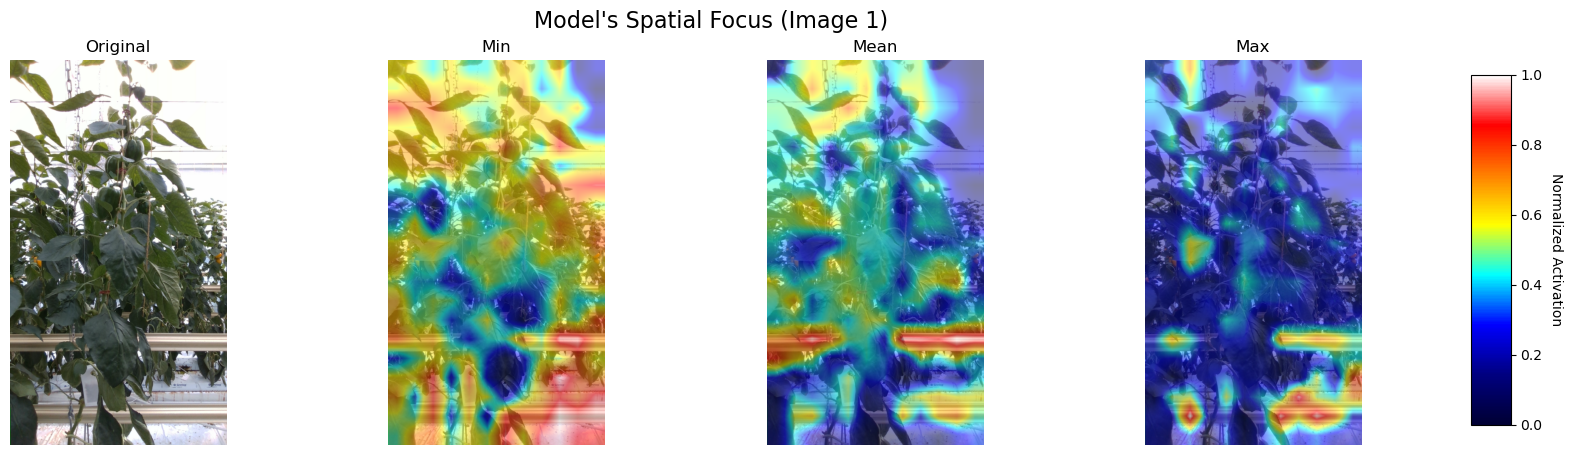


✨ Visualizing feature maps for image 2 from layer: 'model.pixel_level_module.decoder'


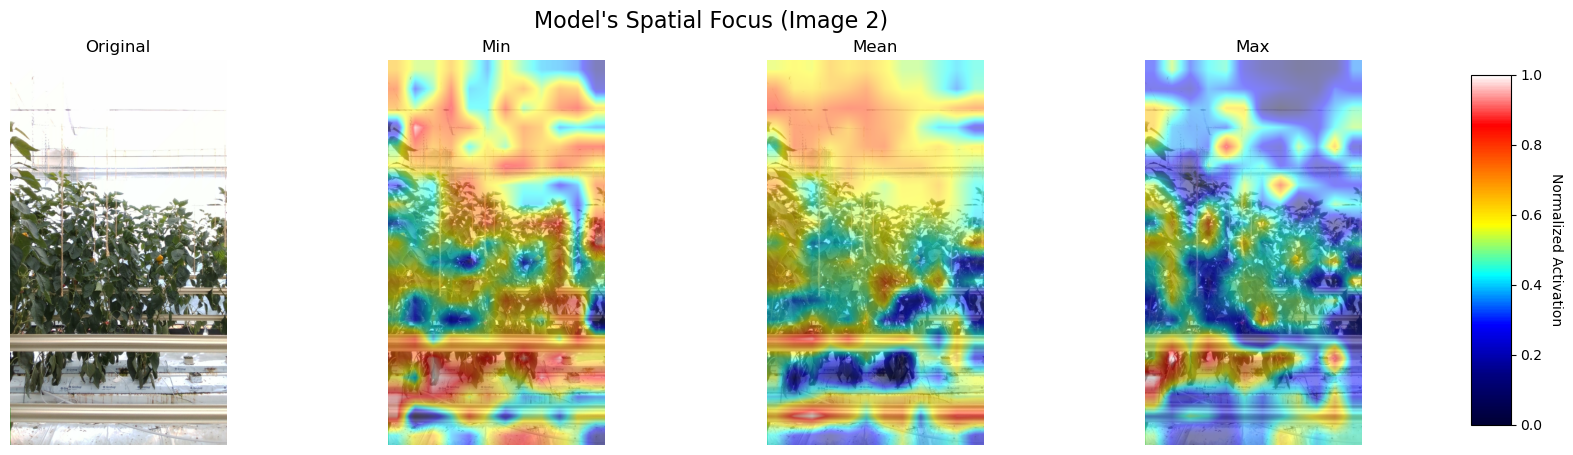


✨ Visualizing feature maps for image 3 from layer: 'model.pixel_level_module.decoder'


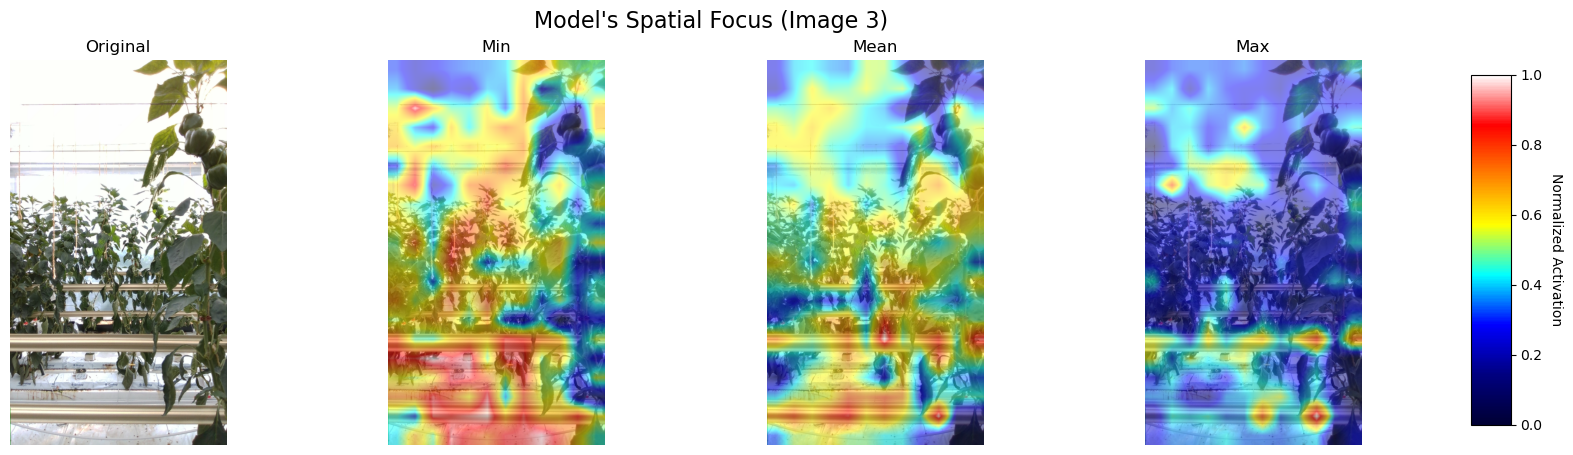

In [ ]:

# --- 3. USAGE EXAMPLE ---
if model:
    try:
        # # Use this for cross-attention visualization
        # TARGET_LAYER_NAME = "model.transformer_module.decoder.layers.2.cross_attn" #layers.2,layers.5, layers.8 have square spatial dims
        # visualizer = FeatureMapVisualizer(model, target_layer_name=TARGET_LAYER_NAME, palette=palette)

        # # Use this for pixel decoder visualization
        TARGET_LAYER_NAME = "model.pixel_level_module.decoder"
        visualizer = FeatureMapVisualizer(model, target_layer_name=TARGET_LAYER_NAME)
        
        num_in_batch = len(batch['pixel_values'])
        images_to_process = min(NUM_IMAGES_TO_VISUALIZE, num_in_batch)
        
        print(f"\nProcessing {images_to_process} images from the batch...")

        for i in range(images_to_process):
            pixel_values_single = batch['pixel_values'][i:i+1]
            original_image_data = batch['original_images'][i]

            if isinstance(original_image_data, np.ndarray):
                original_image_pil = Image.fromarray(original_image_data)
            else:
                original_image_pil = original_image_data
            
            visualizer.visualize(original_image_pil, pixel_values_single, image_index=i)
            
    except Exception as e:
        print(f"❌ An error occurred during visualization. Error: {e}")


✅ Successfully loaded a batch from the test dataloader.
Loading model for 8 classes...


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully (using pretrained weights for demo).
INFO: Cross-attention visualization is not supported for this model as it does not output the required attention maps.

🎨 Visualizing Decoder Self-Attention...
Found 9 decoder self-attention maps (query-to-query).


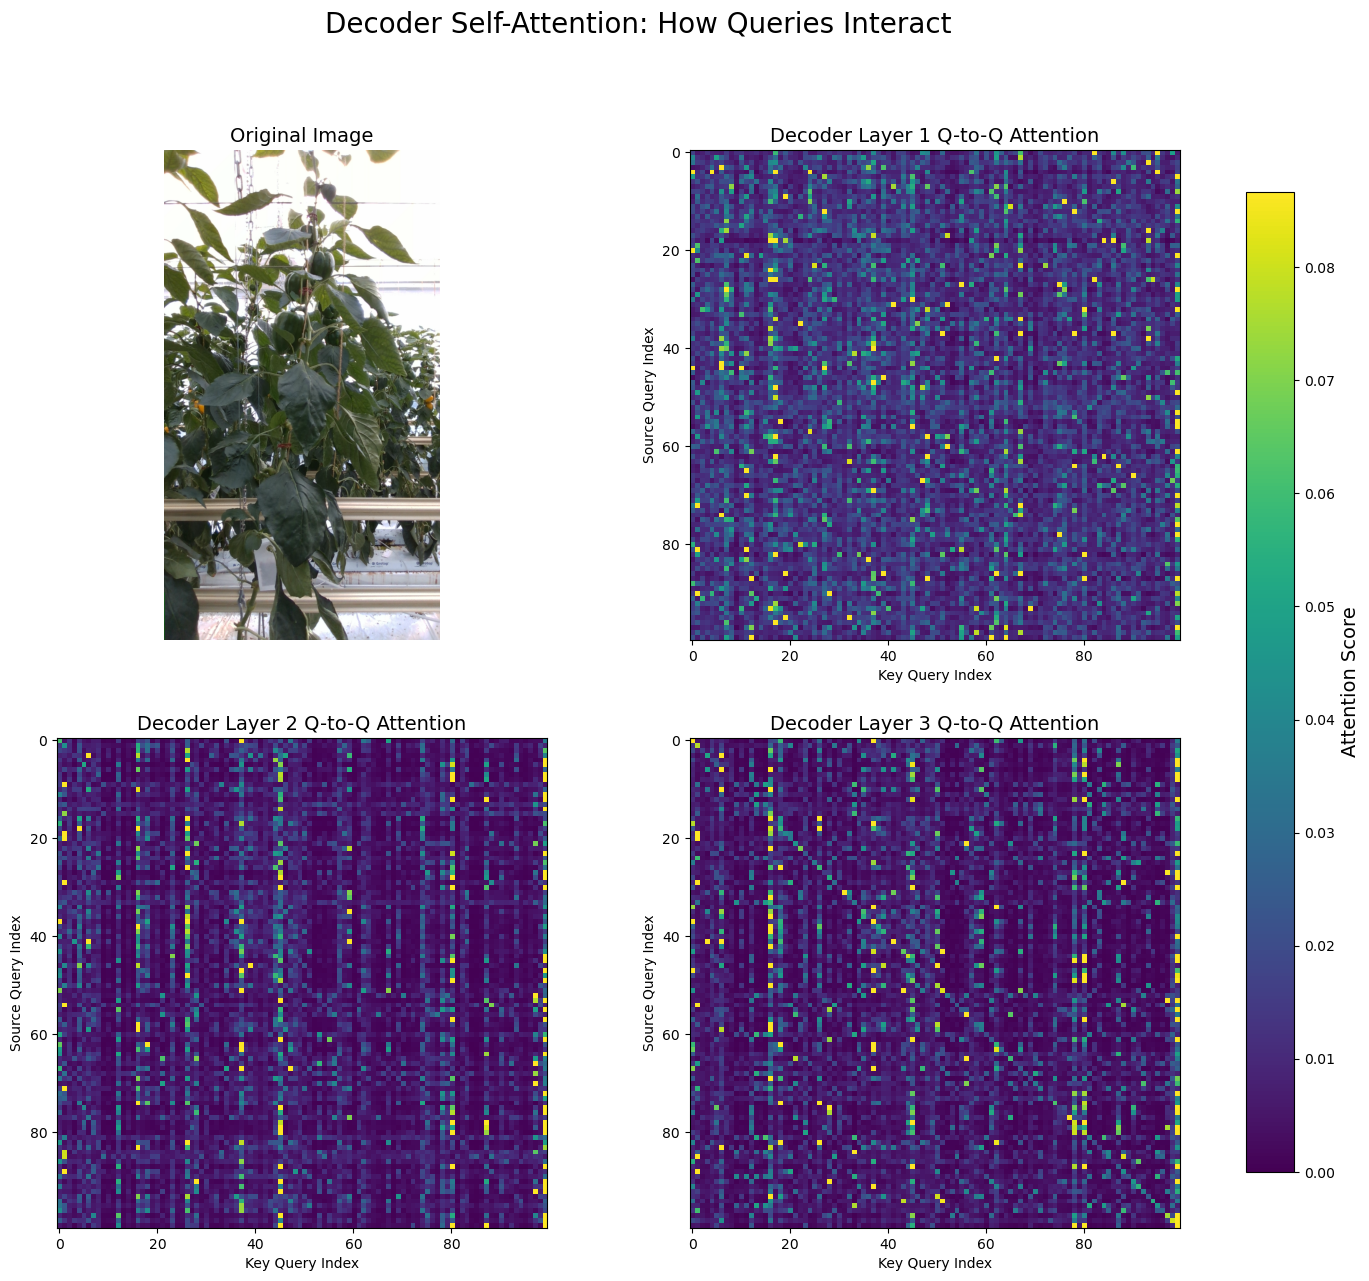

In [70]:
# Import necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# import cv2
import warnings
from transformers import Mask2FormerForUniversalSegmentation

warnings.filterwarnings("ignore")

# --- MOCK SETUP (for standalone execution) ---
try:
    batch = next(iter(test_dataloader))
    print("\n✅ Successfully loaded a batch from the test dataloader.")
except NameError:
    print("⚠️ 'test_dataloader' not found. Creating dummy data for demonstration.")
    dummy_image = Image.new('RGB', (512, 512), color = 'red')
    dummy_pixel_values = torch.randn(1, 3, 512, 512)
    batch = {
        'pixel_values': dummy_pixel_values,
        'original_images': [dummy_image]
    }
    id2label_remapped = {i: f'class_{i}' for i in range(20)}

# --- 1. SETUP AND MODEL LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = len(id2label_remapped)

def get_mask2former_model(num_labels, device):
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        "facebook/mask2former-swin-base-ade-semantic",
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )
    model.to(device)
    return model

try:
    print(f"Loading model for {num_labels} classes...")
    model = get_mask2former_model(num_labels=num_labels, device=device)
    print("✅ Model loaded successfully (using pretrained weights for demo).")
except Exception as e:
    print(f"❌ An error occurred while loading the model: {e}")
    model = None

if model:
    model.eval()

# --- 2. ATTENTION VISUALIZER CLASS (FINAL REVISION) ---
class AttentionVisualizer:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        if self.model: self.model.eval()

    def _get_attention_maps(self, pixel_values):
        with torch.no_grad():
            return self.model(
                pixel_values=pixel_values.to(self.device),
                output_attentions=True,
                return_dict=True
            )

    def visualize_decoder_self_attention(self, original_image_pil, pixel_values):
        if not self.model: return
        print("\n🎨 Visualizing Decoder Self-Attention...")
        outputs = self._get_attention_maps(pixel_values)
        
        all_attentions = outputs.attentions
        if not all_attentions:
            print("No attention maps found in model output.")
            return

        # Decoder self-attentions are maps between object queries.
        # Their shape is (batch_size, num_heads, num_queries, num_queries).
        num_queries = self.model.config.num_queries # Typically 100
        self_attention_maps = [
            attn for attn in all_attentions 
            if attn.shape[-1] == num_queries and attn.shape[-2] == num_queries
        ]

        print(f"Found {len(self_attention_maps)} decoder self-attention maps (query-to-query).")
        if not self_attention_maps:
            print("Could not find any decoder self-attention maps. Skipping visualization.")
            return

        image_np = np.array(original_image_pil)
        num_layers_to_show = min(len(self_attention_maps), 3) # Show up to 3 layers
        
        # Create a 2x2 grid for the original image and up to 3 heatmaps
        fig, axes = plt.subplots(2, 2, figsize=(16, 14))
        fig.suptitle('Decoder Self-Attention: How Queries Interact', fontsize=20, y=0.98)
        
        # Display original image in the top-left subplot
        axes[0, 0].imshow(image_np)
        axes[0, 0].set_title("Original Image", fontsize=14)
        axes[0, 0].axis('off')
        
        heatmap_axes = axes.flat[1:] # Use the remaining 3 subplots for heatmaps
        mappable = None # To store the last plotted heatmap for the colorbar

        for i in range(num_layers_to_show):
            ax = heatmap_axes[i]
            # Average attention scores over all heads
            attention_matrix = self_attention_maps[i].cpu().numpy()[0].mean(axis=0)
            mappable = ax.imshow(attention_matrix, cmap='viridis', vmin=0, vmax=np.percentile(attention_matrix, 99))
            ax.set_title(f"Decoder Layer {i+1} Q-to-Q Attention", fontsize=14)
            ax.set_xlabel("Key Query Index")
            ax.set_ylabel("Source Query Index")
        
        # Turn off any unused subplots in the grid
        for i in range(num_layers_to_show, 3):
            heatmap_axes[i].axis('off')

        # --- COLORBAR FIX ---
        # Add a single colorbar to the figure, positioned nicely.
        # It takes its values from the last heatmap we plotted ('mappable').
        fig.subplots_adjust(right=0.85) # Make room for the colorbar
        cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [left, bottom, width, height]
        cbar = fig.colorbar(mappable, cax=cbar_ax)
        cbar.set_label('Attention Score', fontsize=14)
        
        plt.show()

# --- 3. USAGE EXAMPLE ---
if model:
    try:
        pixel_values = batch['pixel_values'][0:1]
        original_image_pil = batch['original_images'][0]
        
        visualizer = AttentionVisualizer(model, device)
        
        print("INFO: Cross-attention visualization is not supported for this model as it does not output the required attention maps.")
        visualizer.visualize_decoder_self_attention(original_image_pil, pixel_values)
        
    except Exception as e:
        print(f"❌ An error occurred during visualization. Error: {e}")
else:
    print("\nSkipping visualization because the model could not be loaded.")